# 1. Introduction

This notebook constructs five reproducible forget/retain scenarios for the Adult Income baseline experiment and trains a fresh MLP on each retain set.

The experiment is a **model-only full retraining under a fixed preprocessing pipeline**. The forget records are excluded from neural-network training, but the scaler and one-hot encoder loaded from Notebook 1 were fitted on the complete original training set. This is useful because later approximate unlearning methods use the same fixed processed feature matrices. It should not be described as a complete end-to-end deletion procedure, because such a procedure would refit data-dependent preprocessing on each retain set.

The five GDPR-motivated simulated scenarios are:

| Display name | Internal name | Purpose |
|---|---|---|
| Random 1% | `s1_random_1_percent` | Small random deletion request |
| Random 5% | `s2_random_5_percent` | Moderate random deletion request |
| Simulated Data Provider Withdrawal (~5%) | `s3_simulated_data_provider_withdrawal` | Structured organisational deletion request |
| Random 10% | `s4_random_10_percent` | Larger random deletion request |
| Simulated Retention Expiry | `s5_retention_expiry` | Synthetic non-random cohort deletion |

S3 simulates withdrawal of records supplied by one external data provider. This gives the notebook a more realistic structured deletion case alongside the random deletion-size checks.


# 2. Imports and Setup

The notebook imports the standard scientific Python stack, PyTorch, plotting utilities, and simple membership-inference attack tools. Configuration is loaded from Notebook 1's saved baseline checkpoint rather than hardcoded here.


In [1]:
from pathlib import Path
import json
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_val_predict, train_test_split
from scipy.stats import wasserstein_distance
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

notebook_dir = Path.cwd()
project_root = notebook_dir.parents[1]

processed_adult_dir = project_root / "data/processed/adult"
baseline_model_path = project_root / "models/adult/adult_income_baseline_mlp.pt"
baseline_metrics_path = project_root / "results/metrics/adult_baseline_mlp_metrics.csv"
baseline_predictions_path = project_root / "results/tables/adult_baseline_mlp_test_predictions.csv"

results_dir = project_root / "results/full_retraining/adult"
forget_sets_dir = results_dir / "forget_sets"
retain_sets_dir = results_dir / "retain_sets"
models_dir = results_dir / "models"
metrics_dir = results_dir / "metrics"
tables_dir = results_dir / "tables"
figures_dir = results_dir / "figures"
histories_dir = results_dir / "histories"

for output_dir in [
    forget_sets_dir,
    retain_sets_dir,
    models_dir,
    metrics_dir,
    tables_dir,
    figures_dir,
    histories_dir,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

baseline_checkpoint = torch.load(
    baseline_model_path,
    map_location="cpu",
    weights_only=False,
)

required_checkpoint_keys = [
    "random_seed",
    "hidden_layer_dims",
    "dropout_probability",
    "batch_size",
    "learning_rate",
    "max_epochs",
    "early_stopping_patience",
    "early_stopping_min_delta",
    "classification_threshold",
    "processed_feature_names",
    "input_dim",
]
missing_keys = [
    key for key in required_checkpoint_keys
    if key not in baseline_checkpoint
]
if missing_keys:
    raise ValueError(
        "Baseline checkpoint is missing required metadata: "
        f"{missing_keys}"
    )

RANDOM_SEED = int(baseline_checkpoint["random_seed"])
MODEL_TRAINING_SEED = RANDOM_SEED
HIDDEN_LAYER_DIMS = tuple(baseline_checkpoint["hidden_layer_dims"])
DROPOUT_PROBABILITY = float(baseline_checkpoint["dropout_probability"])
BATCH_SIZE = int(baseline_checkpoint["batch_size"])
LEARNING_RATE = float(baseline_checkpoint["learning_rate"])
MAX_EPOCHS = int(baseline_checkpoint["max_epochs"])
EARLY_STOPPING_PATIENCE = int(baseline_checkpoint["early_stopping_patience"])
EARLY_STOPPING_MIN_DELTA = float(baseline_checkpoint["early_stopping_min_delta"])
CLASSIFICATION_THRESHOLD = float(baseline_checkpoint["classification_threshold"])
PROCESSED_FEATURE_NAMES = list(baseline_checkpoint["processed_feature_names"])
INPUT_DIM = int(baseline_checkpoint["input_dim"])
PREPROCESSING_STRATEGY = "fixed_baseline_preprocessing"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(MODEL_TRAINING_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_TRAINING_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"Loaded Notebook 1 baseline checkpoint: {baseline_model_path}")
print(f"Model-training seed: {MODEL_TRAINING_SEED}")
print(f"Classification threshold: {CLASSIFICATION_THRESHOLD}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Preprocessing strategy: {PREPROCESSING_STRATEGY}")


Using device: mps
Loaded Notebook 1 baseline checkpoint: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/models/adult/adult_income_baseline_mlp.pt
Model-training seed: 42
Classification threshold: 0.5
Input dimension: 91
Preprocessing strategy: fixed_baseline_preprocessing


# 3. Load Previous Outputs

The notebook loads the fixed train, validation and test splits created by Notebook 1. No data cleaning, preprocessing fitting, or split creation is repeated here.


In [2]:
# Notebook 2 consumes Notebook 1 artefacts rather than rebuilding preprocessing.
X_train_processed = pd.read_csv(
    processed_adult_dir / "X_train_processed.csv",
    index_col=0,
)
X_val_processed = pd.read_csv(
    processed_adult_dir / "X_val_processed.csv",
    index_col=0,
)
X_test_processed = pd.read_csv(
    processed_adult_dir / "X_test_processed.csv",
    index_col=0,
)

X_train_raw = pd.read_csv(
    processed_adult_dir / "X_train_raw.csv",
    index_col=0,
)
X_val_raw = pd.read_csv(
    processed_adult_dir / "X_val_raw.csv",
    index_col=0,
)
X_test_raw = pd.read_csv(
    processed_adult_dir / "X_test_raw.csv",
    index_col=0,
)

y_train = pd.read_csv(
    processed_adult_dir / "y_train.csv",
    index_col=0,
).squeeze("columns")
y_val = pd.read_csv(
    processed_adult_dir / "y_val.csv",
    index_col=0,
).squeeze("columns")
y_test = pd.read_csv(
    processed_adult_dir / "y_test.csv",
    index_col=0,
).squeeze("columns")

baseline_metrics = (
    pd.read_csv(baseline_metrics_path)
    .set_index("metric")["value"]
    .to_dict()
)
baseline_predictions = pd.read_csv(baseline_predictions_path)

# Input dimensions are checked before any checkpoint is loaded into the MLP.
if X_train_processed.shape[1] != INPUT_DIM:
    raise ValueError(
        "Processed training feature count does not match baseline checkpoint "
        f"input_dim: {X_train_processed.shape[1]} vs {INPUT_DIM}"
    )
if list(X_train_processed.columns) != PROCESSED_FEATURE_NAMES:
    raise ValueError("Processed feature names do not match the baseline checkpoint metadata.")

print(f"Training processed shape: {X_train_processed.shape}")
print(f"Validation processed shape: {X_val_processed.shape}")
print(f"Test processed shape: {X_test_processed.shape}")
print(f"Baseline metrics loaded: {baseline_metrics}")


Training processed shape: (34189, 91)
Validation processed shape: (7326, 91)
Test processed shape: (7327, 91)
Baseline metrics loaded: {'accuracy': 0.8560120103725946, 'f1_score': 0.6750846935632892, 'roc_auc': 0.9096566939119796}


# 4. Synthetic Collection Dates for S5

Adult Income has no true collection timestamp. S5 therefore uses artificial collection dates only to define a simulated date-retention forget set. These dates are not model features, are not attached to validation or test data, and have no historical interpretation.

S5 is a deliberately synthetic, non-random cohort deletion designed to test model behaviour under distribution shift. Workclass-based date offsets make some cohorts systematically older, while record-level jitter adds variation within each cohort. Article 5(1)(e)'s storage-limitation principle motivates the simulated retention-expiry setting, but this notebook is not making a legal determination about any real record.


In [3]:
# The synthetic range gives retention expiry a bounded non-random deletion window.
collection_start_date = pd.Timestamp("2015-01-01")
collection_end_date = pd.Timestamp("2025-12-31")
retention_years = 9
retention_reference_date = collection_end_date
retention_cutoff_date = retention_reference_date - pd.DateOffset(years=retention_years)
retention_date_feature = "workclass"

date_rng = np.random.default_rng(RANDOM_SEED)
date_range_days = (collection_end_date - collection_start_date).days

# Workclass offsets make synthetic dates weakly cohort-dependent instead of uniform noise.
workclass_offset_fraction = {
    "Federal-gov": 0.06,
    "Local-gov": 0.09,
    "State-gov": 0.12,
    "Self-emp-not-inc": 0.16,
    "Self-emp-inc": 0.28,
    "Private": 0.50,
    "Unknown": 0.60,
    "Without-pay": 0.70,
    "Never-worked": 0.80,
}

workclass_values = (
    X_train_raw[retention_date_feature]
    .astype("string")
    .fillna("Unknown")
)
baseline_day_offsets = workclass_values.map(
    lambda value: int(workclass_offset_fraction.get(value, 0.50) * date_range_days)
).to_numpy(dtype=int)

jitter_window_days = 540
record_level_jitter = date_rng.integers(
    low=-jitter_window_days,
    high=jitter_window_days + 1,
    size=len(X_train_raw),
)

synthetic_day_offsets = np.clip(
    baseline_day_offsets + record_level_jitter,
    0,
    date_range_days,
)
synthetic_collection_dates = (
    collection_start_date
    + pd.to_timedelta(synthetic_day_offsets, unit="D")
)

X_train_raw_with_dates = X_train_raw.copy()
X_train_raw_with_dates["collection_date"] = synthetic_collection_dates

workclass_collection_date_offsets = pd.DataFrame(
    {
        "workclass": list(workclass_offset_fraction.keys()),
        "baseline_offset_fraction": list(workclass_offset_fraction.values()),
        "baseline_offset_days": [
            int(offset * date_range_days)
            for offset in workclass_offset_fraction.values()
        ],
    }
)

yearly_collection_distribution = (
    X_train_raw_with_dates["collection_date"]
    .dt.year
    .value_counts()
    .sort_index()
    .rename_axis("collection_year")
    .reset_index(name="record_count")
)

print(f"Synthetic date range: {synthetic_collection_dates.min().date()} to {synthetic_collection_dates.max().date()}")
print(f"Retention cutoff date ({retention_years} years): {retention_cutoff_date.date()}")
display(workclass_collection_date_offsets)
display(yearly_collection_distribution)


Synthetic date range: 2015-01-01 to 2024-12-22
Retention cutoff date (9 years): 2016-12-31


,workclass,baseline_offset_fraction,baseline_offset_days
0,Federal-gov,0.06,241
1,Local-gov,0.09,361
2,State-gov,0.12,482
3,Self-emp-not-inc,0.16,642
4,Self-emp-inc,0.28,1124
5,Private,0.50,2008
6,Unknown,0.60,2410
7,Without-pay,0.70,2811
8,Never-worked,0.80,3213


,collection_year,record_count
0,2015,2992
1,2016,2605
2,2017,2105
3,2018,621
4,2019,8047
5,2020,8615
6,2021,8472
7,2022,666
8,2023,58
9,2024,8


# 5. Construct Forget and Retain Sets

Random scenarios use deletion-selection seeds that are separate from the model-training seed. The S5 retention scenario is derived from the synthetic dates above.

Scenario 3 simulates the withdrawal of data supplied by an external data provider. This represents a realistic organisational deletion request, such as termination of a data-sharing agreement or withdrawal of permission to use a partner dataset.

The Adult Income dataset contains neither genuine data-provider identifiers nor collection metadata. Therefore, provider assignments are simulated solely for experimental purposes and should not be interpreted as real dataset attributes.


In [4]:
def sample_training_indices(index, fraction, seed):
    """Sample a reproducible fraction of training indices."""
    rng = np.random.default_rng(seed)
    index_values = np.array(index)
    sample_size = int(round(len(index_values) * fraction))
    sampled_indices = rng.choice(index_values, size=sample_size, replace=False)
    return np.array(sorted(sampled_indices), dtype=int)


def create_retain_indices(training_index, forget_indices):
    """Return all training indices not in the forget set."""
    retain_indices = sorted(set(training_index) - set(forget_indices))
    return np.array(retain_indices, dtype=int)


def retention_expired_indices(training_data, cutoff_date):
    """Select records with synthetic collection dates before the retention cutoff."""
    expired_records = training_data[training_data["collection_date"] < cutoff_date]
    return np.array(sorted(expired_records.index.to_numpy()), dtype=int)


def create_provider_metadata(index, seed):
    """Create simulated provider metadata without modifying Adult Income features."""
    rng = np.random.default_rng(seed)
    providers = np.array(
        ["Provider_A", "Provider_B", "Provider_C", "Provider_D", "Provider_E"]
    )
    # Provider_E is kept near 5% to model a small provider withdrawal scenario.
    provider_probabilities = np.array([0.25, 0.25, 0.25, 0.20, 0.05])
    assigned_providers = rng.choice(
        providers,
        size=len(index),
        replace=True,
        p=provider_probabilities,
    )
    return pd.DataFrame(
        {
            "original_index": np.array(index, dtype=int),
            "data_provider": assigned_providers,
        }
    ).set_index("original_index")


training_index = np.array(sorted(X_train_processed.index.to_numpy()), dtype=int)
training_index_set = set(training_index)

PROVIDER_ASSIGNMENT_SEED = RANDOM_SEED + 10
WITHDRAWN_PROVIDER = "Provider_E"
training_provider_metadata = create_provider_metadata(
    training_index,
    seed=PROVIDER_ASSIGNMENT_SEED,
)
provider_distribution = (
    training_provider_metadata["data_provider"]
    .value_counts()
    .sort_index()
    .rename_axis("data_provider")
    .reset_index(name="record_count")
)
provider_distribution["percentage_of_training"] = (
    provider_distribution["record_count"] / len(training_index) * 100
)

scenario_configs = [
    {
        "scenario": "s1_random_1_percent",
        "display_name": "Random 1%",
        "selection_rule": "Random sample of 1% of original training records",
        "deletion_seed": RANDOM_SEED,
        "selection_type": "random_fraction",
        "fraction": 0.01,
        "purpose": "Small random deletion request",
    },
    {
        "scenario": "s2_random_5_percent",
        "display_name": "Random 5%",
        "selection_rule": "Random sample of 5% of original training records",
        "deletion_seed": RANDOM_SEED + 1,
        "selection_type": "random_fraction",
        "fraction": 0.05,
        "purpose": "Moderate random deletion request",
    },
    {
        "scenario": "s3_simulated_data_provider_withdrawal",
        "display_name": "Simulated Data Provider Withdrawal (~5%)",
        "selection_rule": f"All records assigned to simulated {WITHDRAWN_PROVIDER}",
        "deletion_seed": PROVIDER_ASSIGNMENT_SEED,
        "selection_type": "provider_withdrawal",
        "fraction": None,
        "provider": WITHDRAWN_PROVIDER,
        "purpose": "External data-provider withdrawal request",
    },
    {
        "scenario": "s4_random_10_percent",
        "display_name": "Random 10%",
        "selection_rule": "Random sample of 10% of original training records",
        "deletion_seed": RANDOM_SEED + 3,
        "selection_type": "random_fraction",
        "fraction": 0.10,
        "purpose": "Larger random deletion request",
    },
    {
        "scenario": "s5_retention_expiry",
        "display_name": "Simulated Retention Expiry",
        "selection_rule": "Synthetic collection date before retention cutoff",
        "deletion_seed": "synthetic dates from RANDOM_SEED",
        "selection_type": "retention_expiry",
        "fraction": None,
        "purpose": "Non-random cohort deletion under distribution shift",
    },
]

forget_indices = {}
retain_indices = {}

# All forget/retain sets are built from the same original training index.
for config in scenario_configs:
    scenario = config["scenario"]
    if config["selection_type"] == "random_fraction":
        forget = sample_training_indices(
            index=training_index,
            fraction=config["fraction"],
            seed=config["deletion_seed"],
        )
    elif config["selection_type"] == "provider_withdrawal":
        provider = config["provider"]
        forget = np.array(
            sorted(
                training_provider_metadata.index[
                    training_provider_metadata["data_provider"] == provider
                ].to_numpy()
            ),
            dtype=int,
        )
    # Retention expiry uses the simulated collection metadata rather than random sampling.
    elif config["selection_type"] == "retention_expiry":
        forget = retention_expired_indices(
            training_data=X_train_raw_with_dates,
            cutoff_date=retention_cutoff_date,
        )
    else:
        raise ValueError(f"Unknown selection type: {config['selection_type']}")

    retain = create_retain_indices(training_index, forget)
    forget_indices[scenario] = forget
    retain_indices[scenario] = retain

# Fixed expected counts catch accidental drift in scenario construction.
expected_random_counts = {
    "s1_random_1_percent": 342,
    "s2_random_5_percent": 1709,
    "s4_random_10_percent": 3419,
}
for scenario, expected_count in expected_random_counts.items():
    actual_count = len(forget_indices[scenario])
    if actual_count != expected_count:
        raise ValueError(
            f"{scenario} forget count is {actual_count}, expected {expected_count}."
        )

s3_forget_count = len(forget_indices["s3_simulated_data_provider_withdrawal"])
s3_forget_percentage = s3_forget_count / len(training_index) * 100
if not 4.5 <= s3_forget_percentage <= 5.5:
    raise ValueError(
        "S3 provider-withdrawal forget set should be approximately 5% of "
        f"training records; got {s3_forget_percentage:.2f}%."
    )

s2_set = set(forget_indices["s2_random_5_percent"])
s3_set = set(forget_indices["s3_simulated_data_provider_withdrawal"])
s2_s3_overlap_count = len(s2_set & s3_set)

print("Simulated provider distribution:")
display(provider_distribution)
print(
    f"Withdrawn provider: {WITHDRAWN_PROVIDER} | "
    f"records={s3_forget_count} ({s3_forget_percentage:.2f}% of training) | "
    f"provider-assignment seed={PROVIDER_ASSIGNMENT_SEED}"
)

print("\nForget-set counts:")
for config in scenario_configs:
    scenario = config["scenario"]
    print(
        f"{config['display_name']}: "
        f"forget={len(forget_indices[scenario])}, "
        f"retain={len(retain_indices[scenario])}"
    )
print(f"S2 random 5% / S3 provider-withdrawal overlap count: {s2_s3_overlap_count}")


Simulated provider distribution:


,data_provider,record_count,percentage_of_training
0,Provider_A,8591,25.127965
1,Provider_B,8482,24.809149
2,Provider_C,8524,24.931996
3,Provider_D,6894,20.164380
4,Provider_E,1698,4.966510


Withdrawn provider: Provider_E | records=1698 (4.97% of training) | provider-assignment seed=52

Forget-set counts:
Random 1%: forget=342, retain=33847
Random 5%: forget=1709, retain=32480
Simulated Data Provider Withdrawal (~5%): forget=1698, retain=32491
Random 10%: forget=3419, retain=30770
Simulated Retention Expiry: forget=5585, retain=28604
S2 random 5% / S3 provider-withdrawal overlap count: 90


# 6. Scenario Verification

The consolidated summary and validation checks make the scenario definitions auditable before any model is trained.


In [5]:
def positive_class_percentage(indices):
    return float(y_train.loc[indices].mean() * 100)

# The scenario summary is the manifest used by downstream notebooks.
scenario_summary_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    forget = forget_indices[scenario]
    retain = retain_indices[scenario]
    scenario_summary_rows.append(
        {
            "display_name": config["display_name"],
            "scenario": scenario,
            "selection_rule": config["selection_rule"],
            "deletion_selection_seed_or_derivation": config["deletion_seed"],
            "forget_count": len(forget),
            "forget_percentage": len(forget) / len(training_index) * 100,
            "retain_count": len(retain),
            "retain_percentage": len(retain) / len(training_index) * 100,
            "forget_positive_class_percentage": positive_class_percentage(forget),
            "retain_positive_class_percentage": positive_class_percentage(retain),
            "purpose": config["purpose"],
        }
    )

scenario_summary = pd.DataFrame(scenario_summary_rows)
display(scenario_summary)

validation_rows = []
class_distribution_rows = []

for config in scenario_configs:
    scenario = config["scenario"]
    forget = forget_indices[scenario]
    retain = retain_indices[scenario]
    forget_set = set(forget)
    retain_set = set(retain)
    combined_set = forget_set | retain_set

    validation = {
        "scenario": scenario,
        "expected_total_size": len(training_index),
        "actual_total_size": len(forget) + len(retain),
        "retain_forget_overlap": len(forget_set & retain_set),
        "complete_training_coverage": combined_set == training_index_set,
        "forget_indices_valid": forget_set.issubset(training_index_set),
        "retain_indices_valid": retain_set.issubset(training_index_set),
    }
    validation["passed"] = (
        validation["actual_total_size"] == validation["expected_total_size"]
        and validation["retain_forget_overlap"] == 0
        and validation["complete_training_coverage"]
        and validation["forget_indices_valid"]
        and validation["retain_indices_valid"]
    )
    validation_rows.append(validation)

    for subset_name, subset_indices in [
        ("forget", forget),
        ("retain", retain),
    ]:
        subset_labels = y_train.loc[subset_indices]
        for class_label, count in subset_labels.value_counts().sort_index().items():
            class_distribution_rows.append(
                {
                    "scenario": scenario,
                    "display_name": config["display_name"],
                    "subset": subset_name,
                    "class_label": int(class_label),
                    "count": int(count),
                    "percentage": float(count / len(subset_labels) * 100),
                }
            )

scenario_validation = pd.DataFrame(validation_rows)
class_distribution_table = pd.DataFrame(class_distribution_rows)

if not scenario_validation["passed"].all():
    display(scenario_validation)
    raise ValueError("At least one scenario validation failed.")

print("All scenario validations passed.")
display(scenario_validation)
display(class_distribution_table)


,display_name,scenario,selection_rule,deletion_selection_seed_or_derivation,forget_count,forget_percentage,retain_count,retain_percentage,forget_positive_class_percentage,retain_positive_class_percentage,purpose
0,Random 1%,s1_random_1_percent,Random sample of 1% of original training records,42,342,1.000322,33847,98.999678,22.222222,23.945992,Small random deletion request
1,Random 5%,s2_random_5_percent,Random sample of 5% of original training records,43,1709,4.998684,32480,95.001316,23.405500,23.956281,Moderate random deletion request
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,All records assigned to simulated Provider_E,52,1698,4.966510,32491,95.033490,24.204947,23.914315,External data-provider withdrawal request
3,Random 10%,s4_random_10_percent,Random sample of 10% of original training records,45,3419,10.000292,30770,89.999708,23.427903,23.984400,Larger random deletion request
4,Simulated Retention Expiry,s5_retention_expiry,Synthetic collection date before retention cutoff,synthetic dates from RANDOM_SEED,5585,16.335664,28604,83.664336,30.814682,22.584254,Non-random cohort deletion under distribution ...


All scenario validations passed.


,scenario,expected_total_size,actual_total_size,retain_forget_overlap,complete_training_coverage,forget_indices_valid,retain_indices_valid,passed
0,s1_random_1_percent,34189,34189,0,True,True,True,True
1,s2_random_5_percent,34189,34189,0,True,True,True,True
2,s3_simulated_data_provider_withdrawal,34189,34189,0,True,True,True,True
3,s4_random_10_percent,34189,34189,0,True,True,True,True
4,s5_retention_expiry,34189,34189,0,True,True,True,True


,scenario,display_name,subset,class_label,count,percentage
0,s1_random_1_percent,Random 1%,forget,0,266,77.777778
1,s1_random_1_percent,Random 1%,forget,1,76,22.222222
2,s1_random_1_percent,Random 1%,retain,0,25742,76.054008
3,s1_random_1_percent,Random 1%,retain,1,8105,23.945992
4,s2_random_5_percent,Random 5%,forget,0,1309,76.594500
5,s2_random_5_percent,Random 5%,forget,1,400,23.405500
6,s2_random_5_percent,Random 5%,retain,0,24699,76.043719
7,s2_random_5_percent,Random 5%,retain,1,7781,23.956281
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),forget,0,1287,75.795053
9,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),forget,1,411,24.204947


## 6.1 S5 Cohort-Shift Checks

The S5 forget set should differ from the overall training set by workclass because the synthetic dates are constructed from workclass-level offsets. This confirms that S5 is not equivalent to a random deletion sample.


In [6]:
s5_forget_indices = forget_indices["s5_retention_expiry"]

s5_workclass_shift_table = pd.DataFrame(
    {
        "overall_training_proportion": (
            X_train_raw[retention_date_feature]
            .value_counts(normalize=True)
        ),
        "s5_forget_proportion": (
            X_train_raw.loc[s5_forget_indices, retention_date_feature]
            .value_counts(normalize=True)
        ),
    }
).fillna(0)
s5_workclass_shift_table["absolute_difference"] = (
    s5_workclass_shift_table["s5_forget_proportion"]
    - s5_workclass_shift_table["overall_training_proportion"]
).abs()
s5_workclass_shift_table = (
    s5_workclass_shift_table
    .sort_values("absolute_difference", ascending=False)
    .rename_axis("workclass")
    .reset_index()
)
largest_s5_workclass_shift = float(
    s5_workclass_shift_table["absolute_difference"].max()
)

s5_class_distribution = class_distribution_table[
    class_distribution_table["scenario"] == "s5_retention_expiry"
]

print(
    "Largest absolute workclass proportion shift for S5: "
    f"{largest_s5_workclass_shift:.4f}"
)
display(s5_workclass_shift_table)
display(s5_class_distribution)


Largest absolute workclass proportion shift for S5: 0.6935


,workclass,overall_training_proportion,s5_forget_proportion,absolute_difference
0,Private,0.693469,0.000000,0.693469
1,Local-gov,0.065489,0.338944,0.273455
2,Self-emp-not-inc,0.078417,0.279678,0.201261
3,State-gov,0.040452,0.182274,0.141822
4,Federal-gov,0.029717,0.170815,0.141098
5,Unknown,0.056334,0.000000,0.056334
6,Self-emp-inc,0.035362,0.028290,0.007072
7,Without-pay,0.000468,0.000000,0.000468
8,Never-worked,0.000292,0.000000,0.000292


,scenario,display_name,subset,class_label,count,percentage
16,s5_retention_expiry,Simulated Retention Expiry,forget,0,3864,69.185318
17,s5_retention_expiry,Simulated Retention Expiry,forget,1,1721,30.814682
18,s5_retention_expiry,Simulated Retention Expiry,retain,0,22144,77.415746
19,s5_retention_expiry,Simulated Retention Expiry,retain,1,6460,22.584254


# 7. Define Model and Training Helpers

Each scenario trains a fresh copy of the same MLP architecture used by Notebook 1. The model-training seed is reset before every scenario so the scenarios start from the same initialisation. The training DataLoader also receives a dedicated seeded generator.


In [7]:
class AdultIncomeMLP(nn.Module):
    """Baseline MLP architecture loaded from Notebook 1 metadata."""

    def __init__(self, input_dim, hidden_layer_dims, dropout_probability):
        super().__init__()
        hidden_dim_1, hidden_dim_2 = hidden_layer_dims
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(hidden_dim_2, 1),
        )

    def forward(self, features):
        return self.network(features)


# Resetting seeds here makes each full-retraining run independently reproducible.
def create_model(seed=MODEL_TRAINING_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return AdultIncomeMLP(
        input_dim=INPUT_DIM,
        hidden_layer_dims=HIDDEN_LAYER_DIMS,
        dropout_probability=DROPOUT_PROBABILITY,
    ).to(device)


def make_tensor_dataset(features, labels):
    feature_tensor = torch.tensor(features.values, dtype=torch.float32)
    label_tensor = torch.tensor(labels.values, dtype=torch.float32).view(-1, 1)
    return TensorDataset(feature_tensor, label_tensor)


def create_data_loader(dataset, batch_size=BATCH_SIZE, shuffle=False, seed=None):
    generator = None
    # A seeded generator makes shuffled retraining batches reproducible.
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(MODEL_TRAINING_SEED if seed is None else seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )


# Validation loss is averaged by record count so partial final batches do not bias it.
def calculate_average_loss(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            total_loss += loss.item() * features.size(0)
    return total_loss / len(data_loader.dataset)


def train_model(model, train_loader, val_loader, verbose=False):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [],
        "val_loss": [],
    }
    best_val_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0
    early_stopping_triggered = False

    for epoch in range(MAX_EPOCHS):
        model.train()
        running_train_loss = 0.0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * features.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)
        val_loss = calculate_average_loss(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Validation loss must beat min_delta before the checkpoint is treated as better.
        improved = val_loss < (best_val_loss - EARLY_STOPPING_MIN_DELTA)
        if improved:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            # Clone weights on CPU so later updates cannot mutate the saved best state.
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
                f"Train loss: {train_loss:.4f} | "
                f"Validation loss: {val_loss:.4f} | "
                f"Best validation loss: {best_val_loss:.4f}"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            early_stopping_triggered = True
            break

    if best_model_state is None:
        raise RuntimeError("No best model state was recorded during training.")

    # Training always ends by restoring the best validation checkpoint.
    model.load_state_dict(
        {key: value.to(device) for key, value in best_model_state.items()}
    )

    history.update(
        {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "early_stopping_triggered": early_stopping_triggered,
            "actual_epochs_run": len(history["train_loss"]),
        }
    )
    return model, history


# 8. Model-Only Full Retraining

For each scenario, the notebook trains a fresh model on the retain set only. Validation data is unchanged and used only for early stopping. Test data is unchanged and used only for final evaluation.

Runtime is reported as **training-loop runtime on the selected device**. It excludes preprocessing, model/DataLoader construction, evaluation, and file saving. Small runtime differences should not be overinterpreted from a single execution.


In [8]:
def retrain_model_for_scenario(config, verbose=False):
    scenario = config["scenario"]
    retain_index = retain_indices[scenario]
    forget_index = forget_indices[scenario]

    X_retain = X_train_processed.loc[retain_index]
    y_retain = y_train.loc[retain_index]

    train_dataset = make_tensor_dataset(X_retain, y_retain)
    val_dataset = make_tensor_dataset(X_val_processed, y_val)

    train_loader = create_data_loader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=MODEL_TRAINING_SEED,
    )
    val_loader = create_data_loader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    # Full retraining starts from the same random initialisation for every scenario.
    model = create_model(seed=MODEL_TRAINING_SEED)

    start_time = time.perf_counter()
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        verbose=verbose,
    )
    runtime_seconds = time.perf_counter() - start_time

    history["runtime_seconds"] = runtime_seconds
    history["runtime_per_epoch"] = runtime_seconds / history["actual_epochs_run"]

    return {
        "scenario": scenario,
        "display_name": config["display_name"],
        "model": model,
        "history": history,
        "retain_count": len(retain_index),
        "forget_count": len(forget_index),
        "deletion_selection_seed_or_derivation": config["deletion_seed"],
    }

retrained_results = {}
training_summary_rows = []

print(f"Training-loop device: {device}")
for config in scenario_configs:
    result = retrain_model_for_scenario(config, verbose=False)
    retrained_results[result["scenario"]] = result
    history = result["history"]
    training_summary_rows.append(
        {
            "display_name": result["display_name"],
            "scenario": result["scenario"],
            "retain_count": result["retain_count"],
            "configured_max_epochs": MAX_EPOCHS,
            "actual_epochs_run": history["actual_epochs_run"],
            "best_epoch": history["best_epoch"],
            "best_val_loss": history["best_val_loss"],
            "early_stopping_triggered": history["early_stopping_triggered"],
            "runtime_seconds": history["runtime_seconds"],
            "runtime_per_epoch": history["runtime_per_epoch"],
        }
    )

training_summary = pd.DataFrame(training_summary_rows)
display(training_summary)


Training-loop device: mps


,display_name,scenario,retain_count,configured_max_epochs,actual_epochs_run,best_epoch,best_val_loss,early_stopping_triggered,runtime_seconds,runtime_per_epoch
0,Random 1%,s1_random_1_percent,33847,20,12,9,0.300915,True,6.158163,0.513180
1,Random 5%,s2_random_5_percent,32480,20,15,12,0.301174,True,6.309743,0.420650
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,32491,20,11,8,0.301764,True,4.582676,0.416607
3,Random 10%,s4_random_10_percent,30770,20,13,10,0.301386,True,5.082448,0.390958
4,Simulated Retention Expiry,s5_retention_expiry,28604,20,14,11,0.302443,True,5.083569,0.363112


# 9. Consolidated Utility Evaluation

The main utility table is shown before the supporting per-scenario reports. It compares every retrained model with the Notebook 1 baseline using the unchanged test set and the fixed baseline classification threshold.


In [9]:
# Prediction order is preserved so record-level joins remain valid later.
def predict_with_model(model, features, batch_size=BATCH_SIZE):
    dataset = TensorDataset(
        torch.tensor(features.values, dtype=torch.float32),
        torch.zeros((len(features), 1), dtype=torch.float32),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    probabilities = []
    with torch.no_grad():
        for batch_features, _ in loader:
            batch_features = batch_features.to(device)
            logits = model(batch_features)
            batch_probabilities = torch.sigmoid(logits)
            probabilities.extend(batch_probabilities.cpu().numpy().ravel())
    return np.array(probabilities)

prediction_rows = []
metrics_rows = []
classification_report_rows = []
confusion_matrix_rows = []
roc_curve_rows = []

for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    model = retrained_results[scenario]["model"]
    probabilities = predict_with_model(model, X_test_processed)
    predictions = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
    y_true = y_test.to_numpy().astype(int)

    for original_index, true_value, probability, prediction in zip(
        X_test_processed.index,
        y_true,
        probabilities,
        predictions,
    ):
        prediction_rows.append(
            {
                "original_index": original_index,
                "display_name": display_name,
                "scenario": scenario,
                "y_true": int(true_value),
                "y_probability": float(probability),
                "y_pred": int(prediction),
            }
        )

    report = classification_report(
        y_true,
        predictions,
        output_dict=True,
        zero_division=0,
    )
    for label, values in report.items():
        row = {
            "display_name": display_name,
            "scenario": scenario,
            "label": label,
        }
        if isinstance(values, dict):
            row.update(values)
        else:
            row["f1-score"] = values
        classification_report_rows.append(row)

    conf_matrix = confusion_matrix(y_true, predictions)
    confusion_matrix_rows.append(
        {
            "display_name": display_name,
            "scenario": scenario,
            "true_<=50K_pred_<=50K": int(conf_matrix[0, 0]),
            "true_<=50K_pred_>50K": int(conf_matrix[0, 1]),
            "true_>50K_pred_<=50K": int(conf_matrix[1, 0]),
            "true_>50K_pred_>50K": int(conf_matrix[1, 1]),
        }
    )

    fpr, tpr, thresholds = roc_curve(y_true, probabilities)
    for fpr_value, tpr_value, threshold_value in zip(fpr, tpr, thresholds):
        roc_curve_rows.append(
            {
                "display_name": display_name,
                "scenario": scenario,
                "false_positive_rate": float(fpr_value),
                "true_positive_rate": float(tpr_value),
                "threshold": float(threshold_value),
            }
        )

    accuracy = accuracy_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    auroc = roc_auc_score(y_true, probabilities)
    precision_positive = precision_score(y_true, predictions, zero_division=0)
    recall_positive = recall_score(y_true, predictions, zero_division=0)
    summary_row = scenario_summary.loc[
        scenario_summary["scenario"] == scenario
    ].iloc[0]
    history = retrained_results[scenario]["history"]
    metrics_rows.append(
        {
            "display_name": display_name,
            "scenario": scenario,
            "forget_count": int(summary_row["forget_count"]),
            "forget_percentage": float(summary_row["forget_percentage"]),
            "retain_count": int(summary_row["retain_count"]),
            "accuracy": accuracy,
            "accuracy_difference_from_baseline": accuracy - baseline_metrics["accuracy"],
            "positive_class_precision": precision_positive,
            "positive_class_recall": recall_positive,
            "f1_score": f1,
            "f1_difference_from_baseline": f1 - baseline_metrics["f1_score"],
            "roc_auc": auroc,
            "roc_auc_difference_from_baseline": auroc - baseline_metrics["roc_auc"],
            "actual_epochs_run": history["actual_epochs_run"],
            "runtime_seconds": history["runtime_seconds"],
        }
    )

retrained_predictions = pd.DataFrame(prediction_rows)
retrained_metrics = pd.DataFrame(metrics_rows)
classification_reports_df = pd.DataFrame(classification_report_rows)
confusion_matrices_df = pd.DataFrame(confusion_matrix_rows)
roc_curves_df = pd.DataFrame(roc_curve_rows)

utility_comparison = retrained_metrics.copy()
display(utility_comparison)


,display_name,scenario,forget_count,forget_percentage,retain_count,accuracy,accuracy_difference_from_baseline,positive_class_precision,positive_class_recall,f1_score,f1_difference_from_baseline,roc_auc,roc_auc_difference_from_baseline,actual_epochs_run,runtime_seconds
0,Random 1%,s1_random_1_percent,342,1.000322,33847,0.857786,0.001774,0.742001,0.621791,0.676598,0.001514,0.909855,0.000199,12,6.158163
1,Random 5%,s2_random_5_percent,1709,4.998684,32480,0.856421,0.000409,0.734762,0.625784,0.675909,0.000824,0.909359,-0.000297,15,6.309743
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,1698,4.966510,32491,0.856012,0.000000,0.745084,0.605248,0.667926,-0.007159,0.910143,0.000486,11,4.582676
3,Random 10%,s4_random_10_percent,3419,10.000292,30770,0.855466,-0.000546,0.732262,0.624073,0.673853,-0.001232,0.909438,-0.000219,13,5.082448
4,Simulated Retention Expiry,s5_retention_expiry,5585,16.335664,28604,0.856285,0.000273,0.747525,0.602966,0.667509,-0.007576,0.908436,-0.001220,14,5.083569


## 9.1 Utility Results Interpretation

The interpretation below is generated from the executed comparison table. Differences are descriptive single-training-seed results, not statistical significance claims.


In [10]:
def pp(value):
    return value * 100

random_order = [
    "s1_random_1_percent",
    "s2_random_5_percent",
    "s4_random_10_percent",
]
random_subset = utility_comparison.set_index("scenario").loc[random_order]
s2_row = utility_comparison.set_index("scenario").loc["s2_random_5_percent"]
s3_row = utility_comparison.set_index("scenario").loc["s3_simulated_data_provider_withdrawal"]
s5_row = utility_comparison.set_index("scenario").loc["s5_retention_expiry"]

monotonic_accuracy = random_subset["accuracy_difference_from_baseline"].is_monotonic_decreasing or random_subset["accuracy_difference_from_baseline"].is_monotonic_increasing
monotonic_f1 = random_subset["f1_difference_from_baseline"].is_monotonic_decreasing or random_subset["f1_difference_from_baseline"].is_monotonic_increasing
monotonic_auroc = random_subset["roc_auc_difference_from_baseline"].is_monotonic_decreasing or random_subset["roc_auc_difference_from_baseline"].is_monotonic_increasing

max_abs_accuracy_delta = utility_comparison["accuracy_difference_from_baseline"].abs().max()
max_abs_f1_delta = utility_comparison["f1_difference_from_baseline"].abs().max()
max_abs_auroc_delta = utility_comparison["roc_auc_difference_from_baseline"].abs().max()

s3_forget_pct = scenario_summary.set_index("scenario").loc[
    "s3_simulated_data_provider_withdrawal",
    "forget_percentage",
]
s5_forget_pos = scenario_summary.set_index("scenario").loc[
    "s5_retention_expiry",
    "forget_positive_class_percentage",
]
s5_retain_pos = scenario_summary.set_index("scenario").loc[
    "s5_retention_expiry",
    "retain_positive_class_percentage",
]
train_pos = float(y_train.mean() * 100)

utility_interpretation = f"""
Across the random deletion scenarios, accuracy differences from the baseline range from {pp(random_subset['accuracy_difference_from_baseline'].min()):.2f} to {pp(random_subset['accuracy_difference_from_baseline'].max()):.2f} percentage points, F1 differences range from {pp(random_subset['f1_difference_from_baseline'].min()):.2f} to {pp(random_subset['f1_difference_from_baseline'].max()):.2f} percentage points, and AUROC differences range from {pp(random_subset['roc_auc_difference_from_baseline'].min()):.2f} to {pp(random_subset['roc_auc_difference_from_baseline'].max()):.2f} percentage points.

S2 and S3 are both approximately 5% deletion settings, but they represent different deletion mechanisms. S2 is a random 5% sample with accuracy {s2_row['accuracy']:.4f}, F1 {s2_row['f1_score']:.4f}, and AUROC {s2_row['roc_auc']:.4f}. S3 removes all records assigned to the simulated withdrawn provider, covering {s3_forget_pct:.2f}% of training records, with accuracy {s3_row['accuracy']:.4f}, F1 {s3_row['f1_score']:.4f}, and AUROC {s3_row['roc_auc']:.4f}. This compares random deletion with a structured organisational withdrawal while keeping the model-training seed fixed.

The random-scenario changes are not strictly monotonic across all metrics: accuracy monotonic={monotonic_accuracy}, F1 monotonic={monotonic_f1}, AUROC monotonic={monotonic_auroc}. Tiny improvements over the baseline should not be interpreted as evidence that deletion improves the model; these are small single-seed differences that can reflect training dynamics and which records were removed.

The largest absolute F1 change is {pp(max_abs_f1_delta):.2f} percentage points, compared with {pp(max_abs_accuracy_delta):.2f} percentage points for accuracy and {pp(max_abs_auroc_delta):.2f} percentage points for AUROC. F1 is more sensitive here because positive-class recall changes directly affect the minority-class harmonic mean.

The S5 retention scenario is different from the random scenarios because it removes a cohort-shifted subset. Its forget set has {s5_forget_pos:.2f}% positive-class records, compared with {s5_retain_pos:.2f}% in the retain set and {train_pos:.2f}% in the original training set. This distribution shift helps explain why its utility behaviour may differ from random deletions of similar or smaller size.
""".strip()

print(utility_interpretation)


Across the random deletion scenarios, accuracy differences from the baseline range from -0.05 to 0.18 percentage points, F1 differences range from -0.12 to 0.15 percentage points, and AUROC differences range from -0.03 to 0.02 percentage points.

S2 and S3 are both approximately 5% deletion settings, but they represent different deletion mechanisms. S2 is a random 5% sample with accuracy 0.8564, F1 0.6759, and AUROC 0.9094. S3 removes all records assigned to the simulated withdrawn provider, covering 4.97% of training records, with accuracy 0.8560, F1 0.6679, and AUROC 0.9101. This compares random deletion with a structured organisational withdrawal while keeping the model-training seed fixed.

The random-scenario changes are not strictly monotonic across all metrics: accuracy monotonic=True, F1 monotonic=True, AUROC monotonic=False. Tiny improvements over the baseline should not be interpreted as evidence that deletion improves the model; these are small single-seed differences that c

# 10. ROC Curves and Supporting Reports

The ROC plot provides a compact visual comparison. Classification reports and confusion matrices are included as supporting diagnostics after the consolidated utility table.


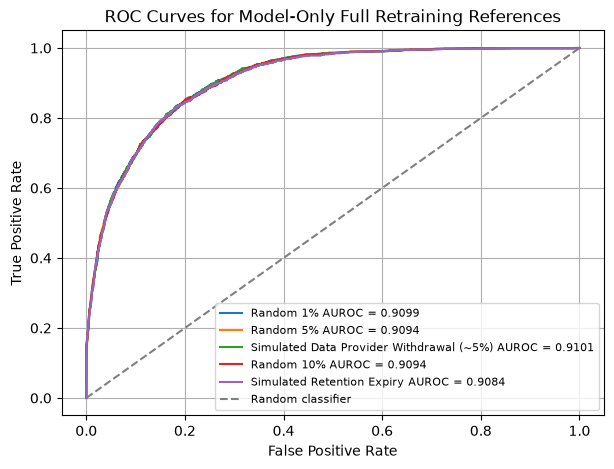

In [11]:
roc_fig, roc_ax = plt.subplots(figsize=(7, 5))
for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    scenario_roc = roc_curves_df[roc_curves_df["scenario"] == scenario]
    scenario_auc = retrained_metrics.loc[
        retrained_metrics["scenario"] == scenario,
        "roc_auc",
    ].iloc[0]
    roc_ax.plot(
        scenario_roc["false_positive_rate"],
        scenario_roc["true_positive_rate"],
        label=f"{display_name} AUROC = {scenario_auc:.4f}",
    )
roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.set_title("ROC Curves for Model-Only Full Retraining References")
roc_ax.legend(loc="lower right", fontsize=8)
roc_ax.grid(True)
plt.show()


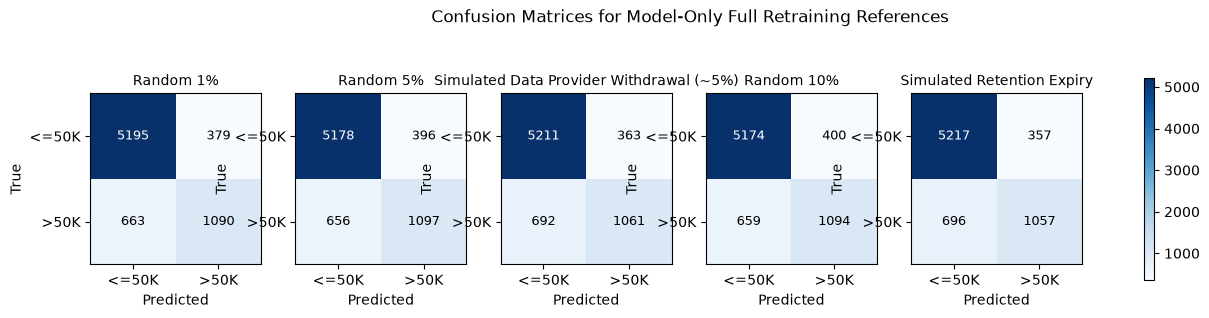


Random 1% (s1_random_1_percent)
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      5574
        >50K       0.74      0.62      0.68      1753

    accuracy                           0.86      7327
   macro avg       0.81      0.78      0.79      7327
weighted avg       0.85      0.86      0.85      7327


Random 5% (s2_random_5_percent)
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      5574
        >50K       0.73      0.63      0.68      1753

    accuracy                           0.86      7327
   macro avg       0.81      0.78      0.79      7327
weighted avg       0.85      0.86      0.85      7327


Simulated Data Provider Withdrawal (~5%) (s3_simulated_data_provider_withdrawal)
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      5574
        >50K       0.75      0.61      0.67      1753

    accuracy                      

In [12]:
fig, axes = plt.subplots(1, len(scenario_configs), figsize=(16, 3.5))
for ax, config in zip(axes, scenario_configs):
    scenario = config["scenario"]
    row = confusion_matrices_df[
        confusion_matrices_df["scenario"] == scenario
    ].iloc[0]
    matrix = np.array(
        [
            [row["true_<=50K_pred_<=50K"], row["true_<=50K_pred_>50K"]],
            [row["true_>50K_pred_<=50K"], row["true_>50K_pred_>50K"]],
        ]
    )
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(config["display_name"], fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1], ["<=50K", ">50K"])
    ax.set_yticks([0, 1], ["<=50K", ">50K"])
    threshold = matrix.max() / 2
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            text_color = "white" if value > threshold else "black"
            ax.text(
                col_idx,
                row_idx,
                int(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
            )
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75)
fig.suptitle("Confusion Matrices for Model-Only Full Retraining References")
plt.show()

for config in scenario_configs:
    scenario = config["scenario"]
    print(f"\n{config['display_name']} ({scenario})")
    scenario_predictions = retrained_predictions[
        retrained_predictions["scenario"] == scenario
    ]
    print(
        classification_report(
            scenario_predictions["y_true"],
            scenario_predictions["y_pred"],
            target_names=["<=50K", ">50K"],
            zero_division=0,
        )
    )


# 11. Membership-Inference Methodology

## 11.1 What MIA Measures

Membership-inference attacks (MIA) test whether a model's outputs expose a detectable signal about whether a record was used during model training. This is separate from the factual ground truth of membership. For example, the original baseline MLP trained on every original training record, so every forget-set record is a known baseline member. If an attack is near chance, that means membership was not detectable by that attack; it does not mean the record was absent from training.

## 11.2 Metrics and Interpretation

This notebook uses **predictive AUROC** for the Adult Income classifier and **attack AUROC** for membership-inference diagnostics.

- Attack AUROC = 0.5 means no useful membership ranking.
- Attack AUROC > 0.5 means members tend to receive higher membership scores.
- Balanced accuracy = 0.5 means chance-level binary membership classification.
- A 95% confidence interval containing 0.5 means there is no reliable above-chance evidence for that attack score.
- TPR at a fixed FPR is the proportion of genuine members detected while limiting false accusations of non-members.
- MIA measures detectable leakage, not whether a record was factually used in training.

## 11.3 Attack Controls

The notebook keeps the transparent direct loss-style attacks, but it does not rely on cross-validated logistic regression on negative loss as the only attack. It adds a frozen shadow-model attack trained only on the validation split as an auxiliary pool. The validation split influenced early stopping in Notebook 1, but it was not used for gradient-based fitting of the baseline or full-retraining models and is kept separate from final MIA evaluation records.

Two controls are used:

- **Negative control:** two disjoint groups of genuine test non-members should be difficult to distinguish.
- **Positive control:** a separate diagnostic MLP is intentionally overfit on a small training subset. It is used only to check whether the attack pipeline can detect leakage when leakage exists; it is not part of the main predictive-performance comparison.

In [13]:
# Larger bootstrap/permutation counts stabilise the diagnostic confidence intervals.
MIA_BOOTSTRAP_RESAMPLES = 2000
MIA_PERMUTATION_RESAMPLES = 1000
# Shadow-model calibration keeps attack thresholds separate from evaluated retrained models.
SHADOW_MODEL_COUNT = 16
SHADOW_EPOCHS = int(min(MAX_EPOCHS, max(5, baseline_checkpoint.get("best_epoch", 10))))
MIA_PRIMARY_ATTACK = "shadow_logistic_score"

DIRECT_ATTACK_COLUMNS = {
    "negative_loss": "negative_model_loss",
    "true_class_confidence": "true_class_confidence",
    "entropy": "negative_entropy",
}
SHADOW_ATTACK_FEATURES = [
    "negative_model_loss",
    "true_class_confidence",
    "negative_entropy",
    "max_probability",
    "probability_margin",
    "correct_prediction",
    "model_probability",
    "true_class",
]


# Direct attacks use per-record loss and confidence signals from the evaluated model.
def per_record_attack_features(
    model,
    features,
    labels,
    model_type,
    scenario,
    subset,
    true_historical_membership,
    batch_size=BATCH_SIZE,
):
    """Calculate per-record features used by direct and shadow MIA attacks."""
    dataset = TensorDataset(
        torch.tensor(features.values, dtype=torch.float32),
        torch.tensor(labels.values, dtype=torch.float32).view(-1, 1),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    losses = []
    probabilities = []
    true_values = []

    model.eval()
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_features)
            batch_probabilities = torch.sigmoid(logits)
            batch_losses = loss_fn(logits, batch_labels)
            losses.extend(batch_losses.cpu().numpy().ravel())
            probabilities.extend(batch_probabilities.cpu().numpy().ravel())
            true_values.extend(batch_labels.cpu().numpy().ravel())

    eps = 1e-12
    losses = np.array(losses)
    probabilities = np.array(probabilities)
    true_values = np.array(true_values).astype(int)
    true_class_probability = np.where(true_values == 1, probabilities, 1 - probabilities)
    max_probability = np.maximum(probabilities, 1 - probabilities)
    entropy = -(
        probabilities * np.log(probabilities + eps)
        + (1 - probabilities) * np.log(1 - probabilities + eps)
    )
    predicted_class = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)

    return pd.DataFrame(
        {
            "original_index": features.index.to_numpy(),
            "model_type": model_type,
            "scenario": scenario,
            "subset": subset,
            "true_historical_membership": true_historical_membership,
            "true_class": true_values,
            "model_probability": probabilities,
            "model_loss": losses,
            "negative_model_loss": -losses,
            "true_class_confidence": true_class_probability,
            "max_probability": max_probability,
            "prediction_entropy": entropy,
            "negative_entropy": -entropy,
            "probability_margin": np.abs(probabilities - 0.5),
            "correct_prediction": (predicted_class == true_values).astype(int),
            "y_pred": predicted_class,
        }
    )


def bootstrap_auc_ci(labels, scores, n_bootstrap=MIA_BOOTSTRAP_RESAMPLES, seed=RANDOM_SEED):
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    rng = np.random.default_rng(seed)
    bootstrap_aucs = []
    for _ in range(n_bootstrap):
        sample_indices = rng.integers(0, len(labels), size=len(labels))
        sampled_labels = labels[sample_indices]
        sampled_scores = scores[sample_indices]
        if len(np.unique(sampled_labels)) < 2:
            continue
        bootstrap_aucs.append(roc_auc_score(sampled_labels, sampled_scores))
    bootstrap_aucs = np.array(bootstrap_aucs)
    return {
        "attack_auc_ci_low": float(np.percentile(bootstrap_aucs, 2.5)),
        "attack_auc_ci_high": float(np.percentile(bootstrap_aucs, 97.5)),
        "attack_auc_bootstrap_samples": int(len(bootstrap_aucs)),
    }


def one_sided_above_chance_permutation_p_value(
    labels,
    scores,
    n_permutations=MIA_PERMUTATION_RESAMPLES,
    seed=RANDOM_SEED,
):
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    observed_auc = roc_auc_score(labels, scores)
    rng = np.random.default_rng(seed)
    permutation_aucs = []
    for _ in range(n_permutations):
        permuted_labels = rng.permutation(labels)
        permutation_aucs.append(roc_auc_score(permuted_labels, scores))
    permutation_aucs = np.array(permutation_aucs)
    p_value = (np.sum(permutation_aucs >= observed_auc) + 1) / (n_permutations + 1)
    return {
        "one_sided_above_chance_permutation_p_value": float(p_value),
        "permutation_resamples": int(n_permutations),
    }


def tpr_at_fixed_fpr(labels, scores, target_fprs=(0.001, 0.01, 0.05)):
    fpr, tpr, _ = roc_curve(labels, scores)
    results = {}
    for target_fpr in target_fprs:
        valid = np.where(fpr <= target_fpr)[0]
        results[f"tpr_at_fpr_{target_fpr}"] = float(tpr[valid].max()) if len(valid) else 0.0
    return results


def threshold_from_calibration(labels, scores):
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores)
    # Calibration searches thresholds on shadow records rather than on evaluated scenarios.
    candidate_thresholds = np.unique(np.quantile(scores, np.linspace(0, 1, 201)))
    best_threshold = float(candidate_thresholds[0])
    best_balanced_accuracy = -np.inf
    for threshold in candidate_thresholds:
        predictions = (scores >= threshold).astype(int)
        balanced_accuracy = balanced_accuracy_score(labels, predictions)
        if balanced_accuracy > best_balanced_accuracy:
            best_balanced_accuracy = balanced_accuracy
            best_threshold = float(threshold)
    return best_threshold, float(best_balanced_accuracy)


def paired_bootstrap_ci(values, n_bootstrap=MIA_BOOTSTRAP_RESAMPLES, seed=RANDOM_SEED):
    values = np.asarray(values)
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_bootstrap):
        sample_indices = rng.integers(0, len(values), size=len(values))
        means.append(values[sample_indices].mean())
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def train_fixed_epoch_model(model, train_loader, epochs, learning_rate):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for _ in range(epochs):
        model.train()
        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
    return model


def create_shadow_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return AdultIncomeMLP(
        input_dim=INPUT_DIM,
        hidden_layer_dims=HIDDEN_LAYER_DIMS,
        dropout_probability=DROPOUT_PROBABILITY,
    ).to(device)


# Frozen attacks prevent scenario results from being inflated by per-scenario recalibration.
def apply_frozen_attacks(records_df):
    records_df = records_df.copy()
    records_df["shadow_logistic_score"] = shadow_logistic_attack.predict_proba(
        records_df[SHADOW_ATTACK_FEATURES]
    )[:, 1]
    records_df["shadow_random_forest_score"] = shadow_random_forest_attack.predict_proba(
        records_df[SHADOW_ATTACK_FEATURES]
    )[:, 1]
    return records_df


def evaluate_attack_scores(
    records_df,
    label_column,
    score_column,
    attack_name,
    calibration_threshold=None,
    calibration_method="fixed threshold 0.5",
    evaluation_split="unspecified",
    include_permutation=False,
):
    labels = records_df[label_column].to_numpy(dtype=int)
    scores = records_df[score_column].to_numpy()
    if len(np.unique(labels)) < 2:
        raise ValueError(f"Evaluation for {attack_name} requires both classes.")
    threshold = 0.5 if calibration_threshold is None else calibration_threshold
    predictions = (scores >= threshold).astype(int)
    metrics = {
        "attack": attack_name,
        "attack_score_column": score_column,
        "attack_auroc": roc_auc_score(labels, scores),
        "attack_balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "threshold": float(threshold),
        "member_count": int((labels == 1).sum()),
        "non_member_count": int((labels == 0).sum()),
        "calibration_method": calibration_method,
        "evaluation_split": evaluation_split,
        "random_seed": RANDOM_SEED,
    }
    metrics.update(bootstrap_auc_ci(labels, scores))
    metrics.update(tpr_at_fixed_fpr(labels, scores))
    if include_permutation:
        metrics.update(one_sided_above_chance_permutation_p_value(labels, scores))
    return metrics


# Class matching reduces label imbalance as a confounder in train-vs-test attacks.
def sample_indices_by_class(source_labels, desired_labels, seed):
    rng = np.random.default_rng(seed)
    sampled_indices = []
    for class_label, desired_count in desired_labels.value_counts().sort_index().items():
        candidates = source_labels[source_labels == class_label].index.to_numpy()
        replace = desired_count > len(candidates)
        sampled_indices.extend(
            rng.choice(candidates, size=int(desired_count), replace=replace).tolist()
        )
    return np.array(sampled_indices, dtype=int)


def sample_test_indices_matched_to_training(member_indices, seed, match_on_workclass=False):
    rng = np.random.default_rng(seed)
    # Workclass matching checks whether S5 sensitivity is driven by cohort composition.
    if not match_on_workclass:
        desired_labels = y_train.loc[member_indices]
        return sample_indices_by_class(y_test, desired_labels, seed)

    sampled_indices = []
    member_frame = pd.DataFrame(
        {
            "income": y_train.loc[member_indices],
            "workclass": X_train_raw.loc[member_indices, "workclass"],
        }
    )
    test_frame = pd.DataFrame(
        {
            "income": y_test,
            "workclass": X_test_raw["workclass"],
        }
    )
    for (income, workclass), group in member_frame.groupby(["income", "workclass"]):
        candidates = test_frame[
            (test_frame["income"] == income)
            & (test_frame["workclass"] == workclass)
        ].index.to_numpy()
        if len(candidates) == 0:
            candidates = test_frame[test_frame["income"] == income].index.to_numpy()
        replace = len(group) > len(candidates)
        sampled_indices.extend(
            rng.choice(candidates, size=len(group), replace=replace).tolist()
        )
    return np.array(sampled_indices, dtype=int)


def evaluate_binary_attack_suite(records_df, label_column, evaluation_split, include_permutation=False):
    rows = []
    for attack_name, score_column in DIRECT_ATTACK_COLUMNS.items():
        rows.append(
            evaluate_attack_scores(
                records_df,
                label_column=label_column,
                score_column=score_column,
                attack_name=attack_name,
                calibration_threshold=direct_attack_thresholds[attack_name],
                calibration_method="threshold selected on shadow auxiliary records",
                evaluation_split=evaluation_split,
                include_permutation=include_permutation,
            )
        )
    rows.append(
        evaluate_attack_scores(
            records_df,
            label_column=label_column,
            score_column="shadow_logistic_score",
            attack_name="shadow_logistic",
            calibration_threshold=0.5,
            calibration_method="frozen class-balanced shadow logistic attack",
            evaluation_split=evaluation_split,
            include_permutation=include_permutation,
        )
    )
    rows.append(
        evaluate_attack_scores(
            records_df,
            label_column=label_column,
            score_column="shadow_random_forest_score",
            attack_name="shadow_random_forest",
            calibration_threshold=0.5,
            calibration_method="frozen class-balanced shadow random forest attack",
            evaluation_split=evaluation_split,
            include_permutation=include_permutation,
        )
    )
    return pd.DataFrame(rows)

## 11.4 Baseline MLP Attack-Sensitivity Results

The code below trains the attack pipeline using validation-only shadow-model experiments, validates it with negative and positive controls, then evaluates the unchanged baseline MLP. The positive-control model is deliberately overfit and is excluded from all main predictive-performance comparisons.

## 11.5 Per-Scenario Baseline Results

For each scenario, the baseline MLP is scored on forget records as known members and on matched test records as known non-members. S5 is reported both as a class-matched cohort-stress result and as a class-plus-workclass matched result.

## 11.6 Full-Retraining Forget-Record Results

The frozen attacks are then applied to the matching fully retrained reference models. This avoids retraining a new attack separately for each target model.

## 11.7 Baseline versus Full-Retraining Comparison

The principal comparison is paired: the same forget records are scored under the original baseline model and under the matching fully retrained reference model.

In [14]:
print("Training validation-only shadow models for MIA attack calibration.")
shadow_records = []
shadow_assignments = []
auxiliary_indices = X_val_processed.index.to_numpy()
auxiliary_labels = y_val.copy()

# Shadow records come only from validation data so calibration is held out from evaluations.
for shadow_id in range(SHADOW_MODEL_COUNT):
    split_seed = RANDOM_SEED + 1000 + shadow_id
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=0.5,
        random_state=split_seed,
    )
    in_position, out_position = next(
        splitter.split(X_val_processed, auxiliary_labels)
    )
    in_indices = auxiliary_indices[in_position]
    out_indices = auxiliary_indices[out_position]

    shadow_assignments.extend(
        [
            {
                "shadow_model_id": shadow_id,
                "original_index": int(index),
                "shadow_membership": 1,
                "split_seed": split_seed,
            }
            for index in in_indices
        ]
    )
    shadow_assignments.extend(
        [
            {
                "shadow_model_id": shadow_id,
                "original_index": int(index),
                "shadow_membership": 0,
                "split_seed": split_seed,
            }
            for index in out_indices
        ]
    )

    shadow_train_dataset = make_tensor_dataset(
        X_val_processed.loc[in_indices],
        y_val.loc[in_indices],
    )
    shadow_train_loader = create_data_loader(
        shadow_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=split_seed,
    )
    shadow_model = create_shadow_model(seed=split_seed)
    shadow_model = train_fixed_epoch_model(
        shadow_model,
        shadow_train_loader,
        epochs=SHADOW_EPOCHS,
        learning_rate=LEARNING_RATE,
    )

    shadow_in_records = per_record_attack_features(
        shadow_model,
        X_val_processed.loc[in_indices],
        y_val.loc[in_indices],
        model_type="shadow_model",
        scenario=f"shadow_{shadow_id}",
        subset="shadow_in",
        true_historical_membership=1,
    )
    shadow_out_records = per_record_attack_features(
        shadow_model,
        X_val_processed.loc[out_indices],
        y_val.loc[out_indices],
        model_type="shadow_model",
        scenario=f"shadow_{shadow_id}",
        subset="shadow_out",
        true_historical_membership=0,
    )
    shadow_in_records["shadow_model_id"] = shadow_id
    shadow_out_records["shadow_model_id"] = shadow_id
    shadow_records.extend([shadow_in_records, shadow_out_records])

mia_shadow_training_records = pd.concat(shadow_records, ignore_index=True)
mia_shadow_membership_assignments = pd.DataFrame(shadow_assignments)

shadow_labels = mia_shadow_training_records["true_historical_membership"].to_numpy(dtype=int)

direct_attack_thresholds = {}
for attack_name, score_column in DIRECT_ATTACK_COLUMNS.items():
    threshold, calibration_balanced_accuracy = threshold_from_calibration(
        shadow_labels,
        mia_shadow_training_records[score_column].to_numpy(),
    )
    direct_attack_thresholds[attack_name] = threshold
    print(
        f"Direct {attack_name} threshold={threshold:.6f}, "
        f"shadow calibration balanced accuracy={calibration_balanced_accuracy:.4f}"
    )

shadow_logistic_attack = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_SEED,
    ),
)
shadow_random_forest_attack = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

shadow_logistic_attack.fit(
    mia_shadow_training_records[SHADOW_ATTACK_FEATURES],
    shadow_labels,
)
shadow_random_forest_attack.fit(
    mia_shadow_training_records[SHADOW_ATTACK_FEATURES],
    shadow_labels,
)

baseline_model = AdultIncomeMLP(
    input_dim=INPUT_DIM,
    hidden_layer_dims=HIDDEN_LAYER_DIMS,
    dropout_probability=DROPOUT_PROBABILITY,
).to(device)
baseline_model.load_state_dict(
    {key: value.to(device) for key, value in baseline_checkpoint["model_state_dict"].items()}
)
baseline_model.eval()

# Negative control: two non-overlapping stratified groups of genuine test non-members.
negative_control_a_indices, negative_control_b_indices = train_test_split(
    X_test_processed.index.to_numpy(),
    test_size=0.5,
    random_state=RANDOM_SEED + 3000,
    stratify=y_test,
)
negative_a = per_record_attack_features(
    baseline_model,
    X_test_processed.loc[negative_control_a_indices],
    y_test.loc[negative_control_a_indices],
    model_type="baseline",
    scenario="negative_control_test_vs_test",
    subset="test_nonmember_group_a",
    true_historical_membership=1,
)
negative_b = per_record_attack_features(
    baseline_model,
    X_test_processed.loc[negative_control_b_indices],
    y_test.loc[negative_control_b_indices],
    model_type="baseline",
    scenario="negative_control_test_vs_test",
    subset="test_nonmember_group_b",
    true_historical_membership=0,
)
# The negative control checks whether the attack reports chance on two non-member groups.
negative_control_records = apply_frozen_attacks(
    pd.concat([negative_a, negative_b], ignore_index=True)
)
negative_control_metrics = evaluate_binary_attack_suite(
    negative_control_records,
    label_column="true_historical_membership",
    evaluation_split="negative_control_test_group_a_vs_test_group_b",
    include_permutation=False,
)
negative_control_metrics["test"] = "Negative control"

# Positive control: deliberately overfit diagnostic MLP, excluded from main comparison.
positive_control_member_indices = sample_indices_by_class(
    y_train,
    pd.Series([0] * 256 + [1] * 256),
    seed=RANDOM_SEED + 4000,
)
positive_control_test_indices = sample_test_indices_matched_to_training(
    positive_control_member_indices,
    seed=RANDOM_SEED + 4001,
)

class DiagnosticOverfitMLP(nn.Module):
    """Diagnostic-only MLP with no dropout for MIA positive control."""

    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, features):
        return self.network(features)

random.seed(RANDOM_SEED + 4100)
np.random.seed(RANDOM_SEED + 4100)
torch.manual_seed(RANDOM_SEED + 4100)
# The positive control checks whether the attack can detect deliberate memorisation.
positive_control_model = DiagnosticOverfitMLP(INPUT_DIM).to(device)
positive_control_dataset = make_tensor_dataset(
    X_train_processed.loc[positive_control_member_indices],
    y_train.loc[positive_control_member_indices],
)
positive_control_loader = create_data_loader(
    positive_control_dataset,
    batch_size=64,
    shuffle=True,
    seed=RANDOM_SEED + 4100,
)
positive_control_model = train_fixed_epoch_model(
    positive_control_model,
    positive_control_loader,
    epochs=250,
    learning_rate=0.01,
)

positive_member_records = per_record_attack_features(
    positive_control_model,
    X_train_processed.loc[positive_control_member_indices],
    y_train.loc[positive_control_member_indices],
    model_type="positive_control_overfit_mlp",
    scenario="positive_control_train_vs_test",
    subset="positive_control_known_member",
    true_historical_membership=1,
)
positive_nonmember_records = per_record_attack_features(
    positive_control_model,
    X_test_processed.loc[positive_control_test_indices],
    y_test.loc[positive_control_test_indices],
    model_type="positive_control_overfit_mlp",
    scenario="positive_control_train_vs_test",
    subset="matched_test_known_nonmember",
    true_historical_membership=0,
)
positive_control_records = apply_frozen_attacks(
    pd.concat([positive_member_records, positive_nonmember_records], ignore_index=True)
)
positive_control_metrics = evaluate_binary_attack_suite(
    positive_control_records,
    label_column="true_historical_membership",
    evaluation_split="positive_control_overfit_train_vs_matched_test",
    include_permutation=True,
)
positive_control_metrics["test"] = "Positive control"

positive_control_train_predictions = (
    positive_member_records["model_probability"] >= CLASSIFICATION_THRESHOLD
).astype(int)
positive_control_test_predictions = (
    positive_nonmember_records["model_probability"] >= CLASSIFICATION_THRESHOLD
).astype(int)
positive_control_performance = pd.DataFrame(
    [
        {
            "split": "positive_control_member_train_subset",
            "accuracy": accuracy_score(
                y_train.loc[positive_control_member_indices],
                positive_control_train_predictions,
            ),
            "f1_score": f1_score(
                y_train.loc[positive_control_member_indices],
                positive_control_train_predictions,
            ),
        },
        {
            "split": "matched_test_nonmembers",
            "accuracy": accuracy_score(
                y_test.loc[positive_control_test_indices],
                positive_control_test_predictions,
            ),
            "f1_score": f1_score(
                y_test.loc[positive_control_test_indices],
                positive_control_test_predictions,
            ),
        },
    ]
)

# Real baseline overall sensitivity, using balanced class-matched groups.
# Overall baseline sensitivity compares known members with class-matched test non-members.
overall_member_indices = sample_indices_by_class(
    y_train,
    y_test,
    seed=RANDOM_SEED + 5000,
)
overall_test_indices = y_test.index.to_numpy()
overall_member_records = per_record_attack_features(
    baseline_model,
    X_train_processed.loc[overall_member_indices],
    y_train.loc[overall_member_indices],
    model_type="baseline",
    scenario="baseline_overall_train_vs_test",
    subset="baseline_train_known_member",
    true_historical_membership=1,
)
overall_nonmember_records = per_record_attack_features(
    baseline_model,
    X_test_processed.loc[overall_test_indices],
    y_test.loc[overall_test_indices],
    model_type="baseline",
    scenario="baseline_overall_train_vs_test",
    subset="test_known_nonmember",
    true_historical_membership=0,
)
overall_baseline_records = apply_frozen_attacks(
    pd.concat([overall_member_records, overall_nonmember_records], ignore_index=True)
)
overall_baseline_metrics = evaluate_binary_attack_suite(
    overall_baseline_records,
    label_column="true_historical_membership",
    evaluation_split="baseline_overall_class_matched_train_vs_test",
    include_permutation=True,
)
overall_baseline_metrics["test"] = "Real baseline overall"

# Per-scenario baseline sensitivity.
baseline_scenario_records = []
baseline_scenario_metric_rows = []
s5_matched_unmatched_rows = []
mia_evaluation_split_rows = []

for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    member_indices = forget_indices[scenario]
    matched_test_indices = sample_test_indices_matched_to_training(
        member_indices,
        seed=RANDOM_SEED + 5100 + len(baseline_scenario_records),
        match_on_workclass=False,
    )
    mia_evaluation_split_rows.append(
        {
            "split_name": f"baseline_{scenario}_class_matched",
            "scenario": scenario,
            "member_count": len(member_indices),
            "nonmember_count": len(matched_test_indices),
            "member_source": "forget_set_known_baseline_members",
            "nonmember_source": "class_matched_test_nonmembers",
            "match_variables": "income_class",
        }
    )

    member_records = per_record_attack_features(
        baseline_model,
        X_train_processed.loc[member_indices],
        y_train.loc[member_indices],
        model_type="baseline",
        scenario=scenario,
        subset="forget_known_baseline_member",
        true_historical_membership=1,
    )
    nonmember_records = per_record_attack_features(
        baseline_model,
        X_test_processed.loc[matched_test_indices],
        y_test.loc[matched_test_indices],
        model_type="baseline",
        scenario=scenario,
        subset="matched_test_known_nonmember",
        true_historical_membership=0,
    )
    scenario_records = apply_frozen_attacks(
        pd.concat([member_records, nonmember_records], ignore_index=True)
    )
    baseline_scenario_records.append(scenario_records)
    scenario_metrics = evaluate_binary_attack_suite(
        scenario_records,
        label_column="true_historical_membership",
        evaluation_split=f"baseline_{scenario}_class_matched_forget_vs_test",
        include_permutation=True,
    )
    scenario_metrics["display_name"] = display_name
    scenario_metrics["scenario"] = scenario
    baseline_scenario_metric_rows.append(scenario_metrics)

    if scenario == "s5_retention_expiry":
        unmatched_test_indices = sample_test_indices_matched_to_training(
            member_indices,
            seed=RANDOM_SEED + 5200,
            match_on_workclass=False,
        )
        workclass_matched_test_indices = sample_test_indices_matched_to_training(
            member_indices,
            seed=RANDOM_SEED + 5201,
            match_on_workclass=True,
        )
        for label, sampled_indices, match_variables in [
            ("S5 class-matched", unmatched_test_indices, "income_class"),
            ("S5 class-and-workclass-matched", workclass_matched_test_indices, "income_class_and_workclass"),
        ]:
            s5_member = per_record_attack_features(
                baseline_model,
                X_train_processed.loc[member_indices],
                y_train.loc[member_indices],
                model_type="baseline",
                scenario="s5_retention_expiry",
                subset="forget_known_baseline_member",
                true_historical_membership=1,
            )
            s5_nonmember = per_record_attack_features(
                baseline_model,
                X_test_processed.loc[sampled_indices],
                y_test.loc[sampled_indices],
                model_type="baseline",
                scenario="s5_retention_expiry",
                subset="matched_test_known_nonmember",
                true_historical_membership=0,
            )
            s5_records = apply_frozen_attacks(pd.concat([s5_member, s5_nonmember], ignore_index=True))
            s5_metrics = evaluate_attack_scores(
                s5_records,
                label_column="true_historical_membership",
                score_column=MIA_PRIMARY_ATTACK,
                attack_name="shadow_logistic",
                calibration_threshold=0.5,
                calibration_method="frozen class-balanced shadow logistic attack",
                evaluation_split=label,
                include_permutation=True,
            )
            s5_metrics["analysis"] = label
            s5_metrics["match_variables"] = match_variables
            s5_matched_unmatched_rows.append(s5_metrics)

baseline_scenario_mia_metrics = pd.concat(baseline_scenario_metric_rows, ignore_index=True)
baseline_scenario_mia_scores = pd.concat(baseline_scenario_records, ignore_index=True)

# Full-retraining reference MIA with frozen attacks.
# Full-retraining MIA treats retain rows as members and forget rows as non-members.
full_retraining_records = []
full_retraining_metric_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    retrained_model = retrained_results[scenario]["model"]
    retain_idx = retain_indices[scenario]
    forget_idx = forget_indices[scenario]
    retain_records = per_record_attack_features(
        retrained_model,
        X_train_processed.loc[retain_idx],
        y_train.loc[retain_idx],
        model_type="full_retraining_reference",
        scenario=scenario,
        subset="retain_training_member",
        true_historical_membership=1,
    )
    forget_records = per_record_attack_features(
        retrained_model,
        X_train_processed.loc[forget_idx],
        y_train.loc[forget_idx],
        model_type="full_retraining_reference",
        scenario=scenario,
        subset="forget_known_nonmember_for_retrained_model",
        true_historical_membership=0,
    )
    records = apply_frozen_attacks(pd.concat([retain_records, forget_records], ignore_index=True))
    full_retraining_records.append(records)
    metrics = evaluate_attack_scores(
        records,
        label_column="true_historical_membership",
        score_column=MIA_PRIMARY_ATTACK,
        attack_name="shadow_logistic",
        calibration_threshold=0.5,
        calibration_method="frozen class-balanced shadow logistic attack",
        evaluation_split=f"full_retraining_{scenario}_retain_vs_forget",
        include_permutation=False,
    )
    metrics["display_name"] = display_name
    metrics["scenario"] = scenario
    full_retraining_metric_rows.append(metrics)

full_retraining_mia_scores = pd.concat(full_retraining_records, ignore_index=True)
mia_metrics_summary = pd.DataFrame(full_retraining_metric_rows)

# Long-format frozen attack scores for baseline, full retraining, controls and positive control.
mia_record_scores = pd.concat(
    [
        negative_control_records.assign(evaluation_block="negative_control"),
        positive_control_records.assign(evaluation_block="positive_control"),
        overall_baseline_records.assign(evaluation_block="baseline_overall"),
        baseline_scenario_mia_scores.assign(evaluation_block="baseline_scenario"),
        full_retraining_mia_scores.assign(evaluation_block="full_retraining_reference"),
    ],
    ignore_index=True,
)

# Paired forget-record score changes from baseline to full retraining.
forget_score_change_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    baseline_forget = baseline_scenario_mia_scores[
        (baseline_scenario_mia_scores["scenario"] == scenario)
        & (baseline_scenario_mia_scores["subset"] == "forget_known_baseline_member")
    ][["original_index", MIA_PRIMARY_ATTACK]]
    full_forget = full_retraining_mia_scores[
        (full_retraining_mia_scores["scenario"] == scenario)
        & (full_retraining_mia_scores["subset"] == "forget_known_nonmember_for_retrained_model")
    ][["original_index", MIA_PRIMARY_ATTACK]]
    paired = baseline_forget.merge(
        full_forget,
        on="original_index",
        suffixes=("_baseline", "_full_retraining"),
    )
    paired_changes = paired[f"{MIA_PRIMARY_ATTACK}_full_retraining"] - paired[f"{MIA_PRIMARY_ATTACK}_baseline"]
    ci_low, ci_high = paired_bootstrap_ci(paired_changes, seed=RANDOM_SEED + 6000)
    change_std = paired_changes.std(ddof=1)
    effect_size = paired_changes.mean() / change_std if change_std > 0 else np.nan

    matched_test_scores = baseline_scenario_mia_scores[
        (baseline_scenario_mia_scores["scenario"] == scenario)
        & (baseline_scenario_mia_scores["subset"] == "matched_test_known_nonmember")
    ][MIA_PRIMARY_ATTACK]
    baseline_distance_to_test = wasserstein_distance(
        paired[f"{MIA_PRIMARY_ATTACK}_baseline"],
        matched_test_scores,
    )
    full_distance_to_test = wasserstein_distance(
        paired[f"{MIA_PRIMARY_ATTACK}_full_retraining"],
        matched_test_scores,
    )

    # Retain controls check whether score shifts are specific to forgotten records.
    retain_sample_idx = sample_indices_by_class(
        y_train.loc[retain_indices[scenario]],
        y_train.loc[forget_indices[scenario]],
        seed=RANDOM_SEED + 6100,
    )
    baseline_retain_records = apply_frozen_attacks(
        per_record_attack_features(
            baseline_model,
            X_train_processed.loc[retain_sample_idx],
            y_train.loc[retain_sample_idx],
            model_type="baseline",
            scenario=scenario,
            subset="retain_control_baseline_member",
            true_historical_membership=1,
        )
    )
    full_retain_records = apply_frozen_attacks(
        per_record_attack_features(
            retrained_results[scenario]["model"],
            X_train_processed.loc[retain_sample_idx],
            y_train.loc[retain_sample_idx],
            model_type="full_retraining_reference",
            scenario=scenario,
            subset="retain_control_full_retraining_member",
            true_historical_membership=1,
        )
    )
    retain_paired = baseline_retain_records[["original_index", MIA_PRIMARY_ATTACK]].merge(
        full_retain_records[["original_index", MIA_PRIMARY_ATTACK]],
        on="original_index",
        suffixes=("_baseline", "_full_retraining"),
    )
    retain_change = (
        retain_paired[f"{MIA_PRIMARY_ATTACK}_full_retraining"]
        - retain_paired[f"{MIA_PRIMARY_ATTACK}_baseline"]
    )

    forget_score_change_rows.append(
        {
            "display_name": display_name,
            "scenario": scenario,
            "attack": "shadow_logistic",
            "baseline_score_mean": paired[f"{MIA_PRIMARY_ATTACK}_baseline"].mean(),
            "baseline_score_median": paired[f"{MIA_PRIMARY_ATTACK}_baseline"].median(),
            "full_retraining_score_mean": paired[f"{MIA_PRIMARY_ATTACK}_full_retraining"].mean(),
            "full_retraining_score_median": paired[f"{MIA_PRIMARY_ATTACK}_full_retraining"].median(),
            "mean_paired_score_change": paired_changes.mean(),
            "paired_change_ci_low": ci_low,
            "paired_change_ci_high": ci_high,
            "standardised_effect_size": effect_size,
            "percentage_decreased": (paired_changes < 0).mean() * 100,
            "baseline_forget_to_matched_test_wasserstein": baseline_distance_to_test,
            "full_retraining_forget_to_matched_test_wasserstein": full_distance_to_test,
            "retain_control_mean_score_change": retain_change.mean(),
            "record_count": len(paired),
        }
    )

mia_forget_score_change_summary = pd.DataFrame(forget_score_change_rows)
mia_control_summary = pd.concat(
    [negative_control_metrics, positive_control_metrics, overall_baseline_metrics],
    ignore_index=True,
)
mia_baseline_sensitivity_summary = pd.concat(
    [overall_baseline_metrics.assign(display_name="Overall training set vs test", scenario="baseline_overall_train_vs_test"), baseline_scenario_mia_metrics],
    ignore_index=True,
)
mia_s5_matched_unmatched_summary = pd.DataFrame(s5_matched_unmatched_rows)
mia_evaluation_split_indices = pd.DataFrame(mia_evaluation_split_rows)

# Split-validation table.
mia_split_validation = pd.DataFrame(
    [
        {
            "check": "shadow_auxiliary_disjoint_from_train",
            "passed": len(set(X_val_processed.index) & set(X_train_processed.index)) == 0,
        },
        {
            "check": "negative_control_groups_disjoint",
            "passed": len(set(negative_control_a_indices) & set(negative_control_b_indices)) == 0,
        },
        {
            "check": "positive_control_members_disjoint_from_test_nonmembers",
            "passed": len(set(positive_control_member_indices) & set(positive_control_test_indices)) == 0,
        },
        {
            "check": "overall_members_disjoint_from_test_nonmembers",
            "passed": len(set(overall_member_indices) & set(overall_test_indices)) == 0,
        },
    ]
)
if not mia_split_validation["passed"].all():
    display(mia_split_validation)
    raise ValueError("At least one MIA split validation failed.")

# Reader-facing compact tables.
control_validation_table = mia_control_summary[
    mia_control_summary["attack"].isin(["shadow_logistic", "negative_loss"])
].copy()
control_validation_table["95% CI"] = control_validation_table.apply(
    lambda row: f"[{row['attack_auc_ci_low']:.4f}, {row['attack_auc_ci_high']:.4f}]",
    axis=1,
)
control_validation_table["Interpretation"] = np.where(
    (control_validation_table["test"] == "Positive control")
    & (control_validation_table["attack_auc_ci_low"] > 0.5),
    "detectable leakage in positive control",
    np.where(
        (control_validation_table["test"] == "Negative control")
        & (control_validation_table["attack_auc_ci_low"] <= 0.5)
        & (control_validation_table["attack_auc_ci_high"] >= 0.5),
        "near chance as expected",
        "inspect result",
    ),
)
control_validation_display = control_validation_table.rename(
    columns={
        "test": "Test",
        "attack": "Attack",
        "attack_auroc": "AUROC",
        "tpr_at_fpr_0.01": "TPR at 1% FPR",
    }
)[["Test", "Attack", "AUROC", "95% CI", "TPR at 1% FPR", "Interpretation"]]

baseline_sensitivity_primary = mia_baseline_sensitivity_summary[
    mia_baseline_sensitivity_summary["attack"] == "shadow_logistic"
].copy()
baseline_sensitivity_primary["95% CI"] = baseline_sensitivity_primary.apply(
    lambda row: f"[{row['attack_auc_ci_low']:.4f}, {row['attack_auc_ci_high']:.4f}]",
    axis=1,
)
baseline_sensitivity_primary["Detectable?"] = np.where(
    baseline_sensitivity_primary["attack_auc_ci_low"] > 0.5,
    "Yes",
    "No / inconclusive",
)
baseline_sensitivity_display = baseline_sensitivity_primary.rename(
    columns={
        "display_name": "Scenario",
        "member_count": "Known members",
        "non_member_count": "Matched non-members",
        "attack_auroc": "Attack AUROC",
        "tpr_at_fpr_0.01": "TPR at 1% FPR",
    }
)[["Scenario", "Known members", "Matched non-members", "Attack AUROC", "95% CI", "TPR at 1% FPR", "Detectable?"]]

forget_score_change_display = mia_forget_score_change_summary.copy()
forget_score_change_display["95% CI"] = forget_score_change_display.apply(
    lambda row: f"[{row['paired_change_ci_low']:.4f}, {row['paired_change_ci_high']:.4f}]",
    axis=1,
)
forget_score_change_display["Interpretation"] = np.where(
    forget_score_change_display["paired_change_ci_high"] < 0,
    "scores decreased after full retraining",
    "change not clearly below zero",
)
forget_score_change_display = forget_score_change_display.rename(
    columns={
        "display_name": "Scenario",
        "baseline_score_mean": "Baseline score",
        "full_retraining_score_mean": "Full-retraining score",
        "mean_paired_score_change": "Paired change",
        "percentage_decreased": "% decreased",
    }
)[["Scenario", "Baseline score", "Full-retraining score", "Paired change", "95% CI", "% decreased", "Interpretation"]]

s5_matched_unmatched_display = mia_s5_matched_unmatched_summary.copy()
s5_matched_unmatched_display["95% CI"] = s5_matched_unmatched_display.apply(
    lambda row: f"[{row['attack_auc_ci_low']:.4f}, {row['attack_auc_ci_high']:.4f}]",
    axis=1,
)
s5_matched_unmatched_display = s5_matched_unmatched_display.rename(
    columns={
        "analysis": "Analysis",
        "attack_auroc": "Attack AUROC",
        "attack_balanced_accuracy": "Balanced accuracy",
        "tpr_at_fpr_0.01": "TPR at 1% FPR",
    }
)[["Analysis", "Attack AUROC", "95% CI", "Balanced accuracy", "TPR at 1% FPR", "match_variables"]]

for display_df in [control_validation_display, baseline_sensitivity_display, forget_score_change_display, s5_matched_unmatched_display]:
    numeric_columns = display_df.select_dtypes(include=["float", "float64"]).columns
    for column in numeric_columns:
        display_df[column] = display_df[column].map(lambda value: f"{value:.4f}")

print("Control validation")
display(control_validation_display)
print("Real baseline sensitivity")
display(baseline_sensitivity_display)
print("Forget-record score changes")
display(forget_score_change_display)
print("S5 matched versus unmatched")
display(s5_matched_unmatched_display)
print("Positive-control performance")
display(positive_control_performance)
print("MIA split validation")
display(mia_split_validation)

Training validation-only shadow models for MIA attack calibration.
Direct negative_loss threshold=-0.294054, shadow calibration balanced accuracy=0.5051
Direct true_class_confidence threshold=0.745236, shadow calibration balanced accuracy=0.5051
Direct entropy threshold=-0.501452, shadow calibration balanced accuracy=0.5024
Control validation


,Test,Attack,AUROC,95% CI,TPR at 1% FPR,Interpretation
0,Negative control,negative_loss,0.5063,"[0.4930, 0.5199]",0.0109,near chance as expected
3,Negative control,shadow_logistic,0.4941,"[0.4808, 0.5078]",0.0060,near chance as expected
5,Positive control,negative_loss,0.6018,"[0.5728, 0.6318]",0.0000,detectable leakage in positive control
8,Positive control,shadow_logistic,0.5993,"[0.5639, 0.6339]",0.0039,detectable leakage in positive control
10,Real baseline overall,negative_loss,0.5012,"[0.4916, 0.5105]",0.0076,inspect result
13,Real baseline overall,shadow_logistic,0.5038,"[0.4945, 0.5130]",0.0097,inspect result


Real baseline sensitivity


,Scenario,Known members,Matched non-members,Attack AUROC,95% CI,TPR at 1% FPR,Detectable?
3,Overall training set vs test,7327,7327,0.5038,"[0.4945, 0.5130]",0.0097,No / inconclusive
8,Random 1%,342,342,0.4806,"[0.4384, 0.5254]",0.0029,No / inconclusive
13,Random 5%,1709,1709,0.5032,"[0.4836, 0.5235]",0.0140,No / inconclusive
18,Simulated Data Provider Withdrawal (~5%),1698,1698,0.5060,"[0.4859, 0.5259]",0.0065,No / inconclusive
23,Random 10%,3419,3419,0.5035,"[0.4891, 0.5175]",0.0126,No / inconclusive
28,Simulated Retention Expiry,5585,5585,0.4934,"[0.4826, 0.5047]",0.0075,No / inconclusive


Forget-record score changes


...

,Analysis,Attack AUROC,95% CI,Balanced accuracy,TPR at 1% FPR,match_variables
0,S5 class-matched,0.4930,"[0.4816, 0.5039]",0.4769,0.0075,income_class
1,S5 class-and-workclass-matched,0.5119,"[0.5010, 0.5227]",0.5140,0.0082,income_class_and_workclass


Positive-control performance


,split,accuracy,f1_score
0,positive_control_member_train_subset,0.992188,0.992188
1,matched_test_nonmembers,0.775391,0.783427


MIA split validation


,check,passed
0,shadow_auxiliary_disjoint_from_train,True
1,negative_control_groups_disjoint,True
2,positive_control_members_disjoint_from_test_no...,True
3,overall_members_disjoint_from_test_nonmembers,True


## 11.8 Findings and Limitations

The findings below are generated from the executed control, baseline-sensitivity and paired score-change tables. They distinguish known membership from detectable membership and avoid treating MIA as standalone evidence of deletion or compliance.

In [15]:
primary_control = mia_control_summary[mia_control_summary["attack"] == "shadow_logistic"]
negative_primary = primary_control[primary_control["test"] == "Negative control"].iloc[0]
positive_primary = primary_control[primary_control["test"] == "Positive control"].iloc[0]
overall_primary = primary_control[primary_control["test"] == "Real baseline overall"].iloc[0]

positive_control_passed = positive_primary["attack_auc_ci_low"] > 0.5
negative_control_passed = negative_primary["attack_auc_ci_low"] <= 0.5 <= negative_primary["attack_auc_ci_high"]
real_baseline_detectable = overall_primary["attack_auc_ci_low"] > 0.5
score_changes_clearly_down = (mia_forget_score_change_summary["paired_change_ci_high"] < 0).sum()
s5_class_matched = mia_s5_matched_unmatched_summary[
    mia_s5_matched_unmatched_summary["analysis"] == "S5 class-matched"
].iloc[0]
s5_workclass_matched = mia_s5_matched_unmatched_summary[
    mia_s5_matched_unmatched_summary["analysis"] == "S5 class-and-workclass-matched"
].iloc[0]

findings_text = f"""
The frozen shadow-logistic attack {'passed' if negative_control_passed else 'did not pass'} the negative control: AUROC {negative_primary['attack_auroc']:.4f} with 95% CI [{negative_primary['attack_auc_ci_low']:.4f}, {negative_primary['attack_auc_ci_high']:.4f}]. It {'passed' if positive_control_passed else 'did not pass'} the positive control: AUROC {positive_primary['attack_auroc']:.4f} with 95% CI [{positive_primary['attack_auc_ci_low']:.4f}, {positive_primary['attack_auc_ci_high']:.4f}].

For the real baseline MLP, the overall class-matched train-versus-test attack AUROC is {overall_primary['attack_auroc']:.4f} with 95% CI [{overall_primary['attack_auc_ci_low']:.4f}, {overall_primary['attack_auc_ci_high']:.4f}]. The real baseline therefore {'exposes a detectable membership signal under this attack' if real_baseline_detectable else 'does not expose a reliable above-chance membership signal under this attack'}, even though the training records are known members by construction.

The paired forget-record analysis shows {score_changes_clearly_down} of {len(mia_forget_score_change_summary)} scenarios with a paired-bootstrap confidence interval entirely below zero for the change from baseline score to full-retraining score. This is the direct before-versus-after MIA comparison on the same forget records.

For S5, the class-matched baseline attack AUROC is {s5_class_matched['attack_auroc']:.4f}; after also matching on workclass it is {s5_workclass_matched['attack_auroc']:.4f}. Any unmatched or weakly matched S5 signal must be interpreted cautiously because the S5 forget set is deliberately cohort-shifted.

Known membership and detectable membership are different. Chance MIA does not prove deletion or privacy, and above-chance MIA alone does not prove GDPR non-compliance. MIA is used here as one supporting diagnostic alongside predictive utility, behavioural similarity and runtime.
""".strip()
print(findings_text)

if not positive_control_passed:
    print(
        "Warning: the positive control did not clearly validate the attack pipeline. "
        "Treat later MIA conclusions as weak or inconclusive."
    )

The frozen shadow-logistic attack passed the negative control: AUROC 0.4941 with 95% CI [0.4808, 0.5078]. It passed the positive control: AUROC 0.5993 with 95% CI [0.5639, 0.6339].

For the real baseline MLP, the overall class-matched train-versus-test attack AUROC is 0.5038 with 95% CI [0.4945, 0.5130]. The real baseline therefore does not expose a reliable above-chance membership signal under this attack, even though the training records are known members by construction.

The paired forget-record analysis shows 5 of 5 scenarios with a paired-bootstrap confidence interval entirely below zero for the change from baseline score to full-retraining score. This is the direct before-versus-after MIA comparison on the same forget records.

For S5, the class-matched baseline attack AUROC is 0.4930; after also matching on workclass it is 0.5119. Any unmatched or weakly matched S5 signal must be interpreted cautiously because the S5 forget set is deliberately cohort-shifted.

Known membership 

# 13. Save Outputs

The notebook saves index files, checkpoints, histories, metrics, tables, figures, the artifact manifest and validation checks. Obsolete generated artifacts for removed scenario names are deleted so the output folder reflects the current five-scenario design.


In [16]:
obsolete_scenario_names = ["s3_different_random_5_percent"]
for obsolete_scenario in obsolete_scenario_names:
    obsolete_paths = [
        forget_sets_dir / f"{obsolete_scenario}_forget_indices.npy",
        retain_sets_dir / f"{obsolete_scenario}_retain_indices.npy",
        models_dir / f"{obsolete_scenario}_retrained_mlp.pt",
        metrics_dir / f"mia_scores_{obsolete_scenario}.csv",
        tables_dir / f"mia_scores_{obsolete_scenario}.csv",
        tables_dir / f"baseline_mia_attack_sensitivity_scores_{obsolete_scenario}_forget_vs_test.csv",
        figures_dir / f"{obsolete_scenario}_confusion_matrix.png",
        figures_dir / "s3_confusion_matrix.png",
        tables_dir / "baseline_full_retraining_mia_context.csv",
        tables_dir / "simulated_data_provider_distribution.csv",
        tables_dir / "simulated_data_provider_assignments.csv",
    ]
    for obsolete_path in obsolete_paths:
        if obsolete_path.exists():
            obsolete_path.unlink()

for config in scenario_configs:
    scenario = config["scenario"]
    np.save(
        forget_sets_dir / f"{scenario}_forget_indices.npy",
        forget_indices[scenario],
    )
    np.save(
        retain_sets_dir / f"{scenario}_retain_indices.npy",
        retain_indices[scenario],
    )

print("Saved forget and retain index arrays.")


Saved forget and retain index arrays.


In [17]:
# Flattened histories make early stopping and runtime auditable across scenarios.
training_history_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    result = retrained_results[scenario]
    history = result["history"]
    model = result["model"]
    model_state_cpu = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }
    checkpoint_path = models_dir / f"{scenario}_retrained_mlp.pt"
    short_checkpoint_path = models_dir / f"s{scenario[1]}_retrained_mlp.pt"
    checkpoint = {
        "model_state_dict": model_state_cpu,
        "scenario": scenario,
        "display_name": config["display_name"],
        "deletion_selection_seed_or_derivation": config["deletion_seed"],
        "model_training_seed": MODEL_TRAINING_SEED,
        "input_dim": INPUT_DIM,
        "processed_feature_names": PROCESSED_FEATURE_NAMES,
        "hidden_layer_dims": HIDDEN_LAYER_DIMS,
        "dropout_probability": DROPOUT_PROBABILITY,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "actual_epochs_run": history["actual_epochs_run"],
        "best_epoch": history["best_epoch"],
        "best_val_loss": history["best_val_loss"],
        "early_stopping_triggered": history["early_stopping_triggered"],
        "retain_count": result["retain_count"],
        "forget_count": result["forget_count"],
        "runtime_seconds": history["runtime_seconds"],
        "preprocessing_strategy": PREPROCESSING_STRATEGY,
    }
    torch.save(checkpoint, checkpoint_path)
    torch.save(checkpoint, short_checkpoint_path)

    for epoch_idx, (train_loss, val_loss) in enumerate(
        zip(history["train_loss"], history["val_loss"]),
        start=1,
    ):
        training_history_rows.append(
            {
                "display_name": config["display_name"],
                "scenario": scenario,
                "epoch": epoch_idx,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "best_epoch": history["best_epoch"],
                "best_val_loss": history["best_val_loss"],
                "early_stopping_triggered": history["early_stopping_triggered"],
            }
        )

training_histories = pd.DataFrame(training_history_rows)
print("Saved retrained model checkpoints.")


Saved retrained model checkpoints.


In [18]:
scenario_summary.to_csv(tables_dir / "scenario_summary.csv", index=False)
scenario_summary.to_csv(tables_dir / "subset_summary.csv", index=False)
class_distribution_table.to_csv(tables_dir / "class_distribution.csv", index=False)
class_distribution_table.to_csv(tables_dir / "subset_class_distribution.csv", index=False)
scenario_validation.to_csv(tables_dir / "scenario_validation_checks.csv", index=False)
s5_workclass_shift_table.to_csv(tables_dir / "s5_workclass_shift.csv", index=False)
workclass_collection_date_offsets.to_csv(tables_dir / "synthetic_date_workclass_offsets.csv", index=False)
yearly_collection_distribution.to_csv(tables_dir / "synthetic_date_yearly_distribution.csv", index=False)

retrained_metrics.to_csv(metrics_dir / "metrics.csv", index=False)
classification_reports_df.to_csv(metrics_dir / "classification_reports.csv", index=False)
confusion_matrices_df.to_csv(metrics_dir / "confusion_matrices.csv", index=False)
roc_curves_df.to_csv(metrics_dir / "roc_curves.csv", index=False)
training_summary.to_csv(metrics_dir / "runtime_summary.csv", index=False)
mia_metrics_summary.to_csv(metrics_dir / "mia_metrics_summary.csv", index=False)
mia_control_summary.to_csv(metrics_dir / "mia_control_summary.csv", index=False)
mia_baseline_sensitivity_summary.to_csv(metrics_dir / "mia_baseline_sensitivity_summary.csv", index=False)
mia_forget_score_change_summary.to_csv(metrics_dir / "mia_forget_score_change_summary.csv", index=False)
mia_s5_matched_unmatched_summary.to_csv(metrics_dir / "mia_s5_matched_unmatched_summary.csv", index=False)
positive_control_performance.to_csv(metrics_dir / "mia_positive_control_performance.csv", index=False)

# Backward-compatible aliases for earlier analysis code.
mia_baseline_sensitivity_summary.to_csv(
    metrics_dir / "baseline_mia_attack_sensitivity_summary.csv",
    index=False,
)
mia_baseline_sensitivity_summary.to_csv(
    metrics_dir / "baseline_mia_attack_sensitivity.csv",
    index=False,
)

retrained_predictions.to_csv(tables_dir / "predictions.csv", index=False)
utility_comparison.to_csv(tables_dir / "utility_comparison.csv", index=False)
utility_comparison.to_csv(tables_dir / "comparison_tables.csv", index=False)
training_histories.to_csv(tables_dir / "training_histories.csv", index=False)
training_histories.to_csv(histories_dir / "training_histories.csv", index=False)

mia_record_scores.to_csv(tables_dir / "mia_record_scores.csv", index=False)
mia_shadow_training_records.to_csv(tables_dir / "mia_shadow_training_records.csv", index=False)
mia_shadow_membership_assignments.to_csv(tables_dir / "mia_shadow_membership_assignments.csv", index=False)
mia_evaluation_split_indices.to_csv(tables_dir / "mia_evaluation_split_indices.csv", index=False)
mia_split_validation.to_csv(tables_dir / "mia_split_validation.csv", index=False)
full_retraining_mia_scores.to_csv(tables_dir / "mia_scores.csv", index=False)
baseline_scenario_mia_scores.to_csv(tables_dir / "baseline_mia_attack_sensitivity_scores.csv", index=False)
overall_baseline_records.to_csv(tables_dir / "baseline_mia_overall_train_vs_test_scores.csv", index=False)
mia_forget_score_change_summary.to_csv(tables_dir / "mia_forget_score_change_summary.csv", index=False)
mia_s5_matched_unmatched_summary.to_csv(tables_dir / "mia_s5_matched_unmatched_summary.csv", index=False)

for scenario, scenario_scores in full_retraining_mia_scores.groupby("scenario"):
    scenario_scores.to_csv(tables_dir / f"mia_scores_{scenario}.csv", index=False)

for scenario, scenario_scores in baseline_scenario_mia_scores.groupby("scenario"):
    scenario_scores.to_csv(
        tables_dir / f"baseline_mia_attack_sensitivity_scores_{scenario}_forget_vs_test.csv",
        index=False,
    )

joblib.dump(shadow_logistic_attack, models_dir / "mia_shadow_logistic.joblib")
joblib.dump(shadow_random_forest_attack, models_dir / "mia_shadow_random_forest.joblib")
mia_attack_metadata = {
    "attack_feature_names": SHADOW_ATTACK_FEATURES,
    "direct_attack_columns": DIRECT_ATTACK_COLUMNS,
    "direct_attack_thresholds": direct_attack_thresholds,
    "primary_attack": MIA_PRIMARY_ATTACK,
    "random_seed": RANDOM_SEED,
    "shadow_model_count": SHADOW_MODEL_COUNT,
    "shadow_epochs": SHADOW_EPOCHS,
    "bootstrap_resamples": MIA_BOOTSTRAP_RESAMPLES,
    "permutation_resamples": MIA_PERMUTATION_RESAMPLES,
    "shadow_auxiliary_pool": "validation split from Notebook 1",
    "positive_control_excluded_from_main_comparison": True,
}
(models_dir / "mia_attack_metadata.json").write_text(
    json.dumps(mia_attack_metadata, indent=2)
)

print("Saved metrics, histories, predictions, MIA outputs and frozen attack models.")

Saved metrics, histories, predictions, MIA outputs and frozen attack models.


In [19]:
roc_fig.savefig(figures_dir / "roc_curves.png", dpi=300, bbox_inches="tight")
fig.savefig(figures_dir / "confusion_matrices_small_multiples.png", dpi=300, bbox_inches="tight")

for config in scenario_configs:
    scenario = config["scenario"]
    row = confusion_matrices_df[confusion_matrices_df["scenario"] == scenario].iloc[0]
    matrix = np.array(
        [
            [row["true_<=50K_pred_<=50K"], row["true_<=50K_pred_>50K"]],
            [row["true_>50K_pred_<=50K"], row["true_>50K_pred_>50K"]],
        ]
    )
    single_fig, single_ax = plt.subplots(figsize=(4, 3.5))
    image = single_ax.imshow(matrix, cmap="Blues")
    single_ax.set_title(config["display_name"])
    single_ax.set_xlabel("Predicted")
    single_ax.set_ylabel("True")
    single_ax.set_xticks([0, 1], ["<=50K", ">50K"])
    single_ax.set_yticks([0, 1], ["<=50K", ">50K"])
    threshold = matrix.max() / 2
    for row_idx in range(2):
        for col_idx in range(2):
            value = matrix[row_idx, col_idx]
            single_ax.text(
                col_idx,
                row_idx,
                int(value),
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )
    single_fig.colorbar(image, ax=single_ax)
    single_fig.savefig(
        figures_dir / f"{scenario}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(single_fig)

# MIA score-distribution plots.
def plot_score_distribution(records, title, output_name):
    plot_fig, plot_ax = plt.subplots(figsize=(6, 4))
    for membership, label in [(0, "Non-member"), (1, "Member")]:
        values = records.loc[
            records["true_historical_membership"] == membership,
            MIA_PRIMARY_ATTACK,
        ]
        plot_ax.hist(values, bins=30, alpha=0.55, density=True, label=label)
    plot_ax.set_title(title)
    plot_ax.set_xlabel("Shadow-logistic membership score")
    plot_ax.set_ylabel("Density")
    plot_ax.legend()
    plot_ax.grid(True, alpha=0.25)
    plot_fig.savefig(figures_dir / output_name, dpi=300, bbox_inches="tight")
    plt.close(plot_fig)

plot_score_distribution(
    negative_control_records,
    "Negative Control MIA Scores",
    "mia_negative_control_score_distribution.png",
)
plot_score_distribution(
    positive_control_records,
    "Positive Control MIA Scores",
    "mia_positive_control_score_distribution.png",
)
plot_score_distribution(
    overall_baseline_records,
    "Real Baseline Overall MIA Scores",
    "mia_real_baseline_score_distribution.png",
)

score_change_plot_data = []
for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    baseline_values = baseline_scenario_mia_scores[
        (baseline_scenario_mia_scores["scenario"] == scenario)
        & (baseline_scenario_mia_scores["subset"] == "forget_known_baseline_member")
    ][MIA_PRIMARY_ATTACK]
    full_values = full_retraining_mia_scores[
        (full_retraining_mia_scores["scenario"] == scenario)
        & (full_retraining_mia_scores["subset"] == "forget_known_nonmember_for_retrained_model")
    ][MIA_PRIMARY_ATTACK]
    score_change_plot_data.append(
        pd.DataFrame(
            {
                "display_name": display_name,
                "model": "Baseline",
                "score": baseline_values.to_numpy(),
            }
        )
    )
    score_change_plot_data.append(
        pd.DataFrame(
            {
                "display_name": display_name,
                "model": "Full retraining",
                "score": full_values.to_numpy(),
            }
        )
    )
score_change_plot_df = pd.concat(score_change_plot_data, ignore_index=True)

box_fig, box_ax = plt.subplots(figsize=(10, 4.5))
labels = []
positions = []
values = []
position = 1
for display_name in [config["display_name"] for config in scenario_configs]:
    for model_name in ["Baseline", "Full retraining"]:
        subset_values = score_change_plot_df[
            (score_change_plot_df["display_name"] == display_name)
            & (score_change_plot_df["model"] == model_name)
        ]["score"]
        values.append(subset_values)
        labels.append(f"{display_name}\n{model_name}")
        positions.append(position)
        position += 1
    position += 0.5
box_ax.boxplot(values, positions=positions, showfliers=False)
box_ax.set_xticks(positions, labels, rotation=45, ha="right")
box_ax.set_ylabel("Shadow-logistic membership score")
box_ax.set_title("Baseline vs Full-Retraining Forget-Record Scores")
box_ax.grid(True, axis="y", alpha=0.25)
box_fig.tight_layout()
box_fig.savefig(figures_dir / "mia_baseline_vs_full_retraining_forget_scores.png", dpi=300, bbox_inches="tight")
plt.close(box_fig)

bar_fig, bar_ax = plt.subplots(figsize=(8, 4))
bar_positions = np.arange(len(mia_forget_score_change_summary))
bar_ax.bar(
    bar_positions,
    mia_forget_score_change_summary["mean_paired_score_change"],
    color=["tab:orange" if name == "Simulated Retention Expiry" else "tab:blue" for name in mia_forget_score_change_summary["display_name"]],
)
bar_ax.axhline(0, color="black", linewidth=1)
bar_ax.set_xticks(bar_positions, mia_forget_score_change_summary["display_name"], rotation=30, ha="right")
bar_ax.set_ylabel("Mean paired score change")
bar_ax.set_title("Forget-Record Membership Score Change")
bar_ax.grid(True, axis="y", alpha=0.25)
bar_fig.tight_layout()
bar_fig.savefig(figures_dir / "mia_forget_score_change_by_scenario.png", dpi=300, bbox_inches="tight")
plt.close(bar_fig)

print("Saved figures.")

Saved figures.


In [20]:
def project_relative(path):
    return str(Path(path).resolve().relative_to(project_root.resolve()))

manifest_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    manifest_rows.append(
        {
            "display_name": config["display_name"],
            "scenario": scenario,
            "forget_indices_path": project_relative(forget_sets_dir / f"{scenario}_forget_indices.npy"),
            "retain_indices_path": project_relative(retain_sets_dir / f"{scenario}_retain_indices.npy"),
            "checkpoint_path": project_relative(models_dir / f"{scenario}_retrained_mlp.pt"),
            "forget_count": len(forget_indices[scenario]),
            "forget_percentage": len(forget_indices[scenario]) / len(training_index) * 100,
            "retain_count": len(retain_indices[scenario]),
            "retain_percentage": len(retain_indices[scenario]) / len(training_index) * 100,
            "deletion_selection_seed_or_derivation": config["deletion_seed"],
            "model_training_seed": MODEL_TRAINING_SEED,
            "preprocessing_strategy": PREPROCESSING_STRATEGY,
            "retrained_mia_scores_path": project_relative(tables_dir / f"mia_scores_{scenario}.csv"),
            "baseline_mia_forget_vs_test_scores_path": project_relative(
                tables_dir / f"baseline_mia_attack_sensitivity_scores_{scenario}_forget_vs_test.csv"
            ),
            "mia_record_scores_path": project_relative(tables_dir / "mia_record_scores.csv"),
            "mia_shadow_logistic_path": project_relative(models_dir / "mia_shadow_logistic.joblib"),
            "mia_shadow_random_forest_path": project_relative(models_dir / "mia_shadow_random_forest.joblib"),
            "mia_attack_metadata_path": project_relative(models_dir / "mia_attack_metadata.json"),
        }
    )
artifact_manifest = pd.DataFrame(manifest_rows)

artifact_validation_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    saved_forget = np.load(forget_sets_dir / f"{scenario}_forget_indices.npy")
    saved_retain = np.load(retain_sets_dir / f"{scenario}_retain_indices.npy")
    checkpoint_path = models_dir / f"{scenario}_retrained_mlp.pt"
    baseline_mia_path = tables_dir / f"baseline_mia_attack_sensitivity_scores_{scenario}_forget_vs_test.csv"
    artifact_validation_rows.append(
        {
            "scenario": scenario,
            "forget_indices_match_memory": np.array_equal(saved_forget, forget_indices[scenario]),
            "retain_indices_match_memory": np.array_equal(saved_retain, retain_indices[scenario]),
            "checkpoint_exists": checkpoint_path.exists(),
            "baseline_mia_scores_exist": baseline_mia_path.exists(),
            "mia_record_scores_exist": (tables_dir / "mia_record_scores.csv").exists(),
            "mia_shadow_logistic_exists": (models_dir / "mia_shadow_logistic.joblib").exists(),
            "mia_shadow_random_forest_exists": (models_dir / "mia_shadow_random_forest.joblib").exists(),
            "mia_attack_metadata_exists": (models_dir / "mia_attack_metadata.json").exists(),
            "no_retain_forget_overlap": len(set(saved_forget) & set(saved_retain)) == 0,
            "reconstructs_training_indices": set(saved_forget) | set(saved_retain) == training_index_set,
        }
    )
artifact_validation_checks = pd.DataFrame(artifact_validation_rows)
artifact_validation_checks["passed"] = artifact_validation_checks.drop(
    columns=["scenario"]
).all(axis=1)

if not artifact_validation_checks["passed"].all():
    display(artifact_validation_checks)
    raise ValueError("At least one saved artifact validation failed.")

artifact_manifest.to_csv(tables_dir / "artifact_manifest.csv", index=False)
artifact_validation_checks.to_csv(tables_dir / "artifact_manifest_checks.csv", index=False)

display(artifact_manifest)
display(artifact_validation_checks)
print("Artifact manifest and validation checks saved.")

,display_name,scenario,forget_indices_path,retain_indices_path,checkpoint_path,forget_count,forget_percentage,retain_count,retain_percentage,deletion_selection_seed_or_derivation,model_training_seed,preprocessing_strategy,retrained_mia_scores_path,baseline_mia_forget_vs_test_scores_path,mia_record_scores_path,mia_shadow_logistic_path,mia_shadow_random_forest_path,mia_attack_metadata_path
0,Random 1%,s1_random_1_percent,results/full_retraining/adult/forget_sets/s1_r...,results/full_retraining/adult/retain_sets/s1_r...,results/full_retraining/adult/models/s1_random...,342,1.000322,33847,98.999678,42,42,fixed_baseline_preprocessing,results/full_retraining/adult/tables/mia_score...,results/full_retraining/adult/tables/baseline_...,results/full_retraining/adult/tables/mia_recor...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_attac...
1,Random 5%,s2_random_5_percent,results/full_retraining/adult/forget_sets/s2_r...,results/full_retraining/adult/retain_sets/s2_r...,results/full_retraining/adult/models/s2_random...,1709,4.998684,32480,95.001316,43,42,fixed_baseline_preprocessing,results/full_retraining/adult/tables/mia_score...,results/full_retraining/adult/tables/baseline_...,results/full_retraining/adult/tables/mia_recor...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_attac...
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,results/full_retraining/adult/forget_sets/s3_s...,results/full_retraining/adult/retain_sets/s3_s...,results/full_retraining/adult/models/s3_simula...,1698,4.966510,32491,95.033490,52,42,fixed_baseline_preprocessing,results/full_retraining/adult/tables/mia_score...,results/full_retraining/adult/tables/baseline_...,results/full_retraining/adult/tables/mia_recor...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_attac...
3,Random 10%,s4_random_10_percent,results/full_retraining/adult/forget_sets/s4_r...,results/full_retraining/adult/retain_sets/s4_r...,results/full_retraining/adult/models/s4_random...,3419,10.000292,30770,89.999708,45,42,fixed_baseline_preprocessing,results/full_retraining/adult/tables/mia_score...,results/full_retraining/adult/tables/baseline_...,results/full_retraining/adult/tables/mia_recor...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_attac...
4,Simulated Retention Expiry,s5_retention_expiry,results/full_retraining/adult/forget_sets/s5_r...,results/full_retraining/adult/retain_sets/s5_r...,results/full_retraining/adult/models/s5_retent...,5585,16.335664,28604,83.664336,synthetic dates from RANDOM_SEED,42,fixed_baseline_preprocessing,results/full_retraining/adult/tables/mia_score...,results/full_retraining/adult/tables/baseline_...,results/full_retraining/adult/tables/mia_recor...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_shado...,results/full_retraining/adult/models/mia_attac...


,scenario,forget_indices_match_memory,retain_indices_match_memory,checkpoint_exists,baseline_mia_scores_exist,mia_record_scores_exist,mia_shadow_logistic_exists,mia_shadow_random_forest_exists,mia_attack_metadata_exists,no_retain_forget_overlap,reconstructs_training_indices,passed
0,s1_random_1_percent,True,True,True,True,True,True,True,True,True,True,True
1,s2_random_5_percent,True,True,True,True,True,True,True,True,True,True,True
2,s3_simulated_data_provider_withdrawal,True,True,True,True,True,True,True,True,True,True,True
3,s4_random_10_percent,True,True,True,True,True,True,True,True,True,True,True
4,s5_retention_expiry,True,True,True,True,True,True,True,True,True,True,True


Artifact manifest and validation checks saved.


# 14. Summary

This notebook created five reproducible GDPR-motivated simulated forget/retain scenarios and trained model-only full-retraining references under Notebook 1's fixed preprocessing pipeline. The scaler and encoder were not refitted, so these references are model-level gold-standard comparisons for later approximate unlearning methods rather than complete end-to-end deletion procedures.

The saved outputs include scenario indices, class-distribution checks, S5 cohort-shift checks, retrained checkpoints, utility metrics, retrained-model MIA diagnostics, baseline MIA attack-sensitivity diagnostics, runtime summaries, histories, figures, and an artifact manifest.

In [21]:
summary_table = utility_comparison.merge(
    mia_metrics_summary[
        ["scenario", "attack_balanced_accuracy", "attack_auroc"]
    ],
    on="scenario",
    how="left",
)
summary_table = summary_table[
    [
        "display_name",
        "scenario",
        "forget_count",
        "forget_percentage",
        "retain_count",
        "accuracy",
        "f1_score",
        "roc_auc",
        "attack_balanced_accuracy",
        "attack_auroc",
        "actual_epochs_run",
        "runtime_seconds",
    ]
]
display(summary_table)

print("Final scenario sizes:")
for _, row in scenario_summary.iterrows():
    print(
        f"{row['display_name']}: forget={int(row['forget_count'])} "
        f"({row['forget_percentage']:.2f}%), retain={int(row['retain_count'])}"
    )

primary_control = mia_control_summary[mia_control_summary["attack"] == "shadow_logistic"]
negative_primary = primary_control[primary_control["test"] == "Negative control"].iloc[0]
positive_primary = primary_control[primary_control["test"] == "Positive control"].iloc[0]
overall_primary = primary_control[primary_control["test"] == "Real baseline overall"].iloc[0]
positive_control_passed = positive_primary["attack_auc_ci_low"] > 0.5
negative_control_passed = negative_primary["attack_auc_ci_low"] <= 0.5 <= negative_primary["attack_auc_ci_high"]
real_baseline_detectable = overall_primary["attack_auc_ci_low"] > 0.5

print("\nMIA control status:")
print(
    f"Negative control shadow-logistic AUROC={negative_primary['attack_auroc']:.4f}, "
    f"95% CI=[{negative_primary['attack_auc_ci_low']:.4f}, {negative_primary['attack_auc_ci_high']:.4f}], "
    f"passed={negative_control_passed}"
)
print(
    f"Positive control shadow-logistic AUROC={positive_primary['attack_auroc']:.4f}, "
    f"95% CI=[{positive_primary['attack_auc_ci_low']:.4f}, {positive_primary['attack_auc_ci_high']:.4f}], "
    f"passed={positive_control_passed}"
)
print(
    f"Real baseline overall shadow-logistic AUROC={overall_primary['attack_auroc']:.4f}, "
    f"95% CI=[{overall_primary['attack_auc_ci_low']:.4f}, {overall_primary['attack_auc_ci_high']:.4f}], "
    f"detectable={real_baseline_detectable}"
)

print("\nBaseline scenario sensitivity, primary shadow-logistic attack:")
for _, row in baseline_sensitivity_display.iterrows():
    print(
        f"{row['Scenario']}: AUROC={row['Attack AUROC']}, "
        f"CI={row['95% CI']}, detectable={row['Detectable?']}"
    )

print("\nForget-record score-change summary:")
for _, row in forget_score_change_display.iterrows():
    print(
        f"{row['Scenario']}: baseline={row['Baseline score']}, "
        f"full_retraining={row['Full-retraining score']}, "
        f"change={row['Paired change']}, CI={row['95% CI']}, "
        f"decreased={row['% decreased']}%"
    )

print(
    "\nKnown membership and detectable membership are different. MIA remains one "
    "diagnostic alongside utility, behavioural similarity and runtime."
)

print("\nSaved outputs under:")
print(results_dir)

,display_name,scenario,forget_count,forget_percentage,retain_count,accuracy,f1_score,roc_auc,attack_balanced_accuracy,attack_auroc,actual_epochs_run,runtime_seconds
0,Random 1%,s1_random_1_percent,342,1.000322,33847,0.857786,0.676598,0.909855,0.505622,0.510490,12,6.158163
1,Random 5%,s2_random_5_percent,1709,4.998684,32480,0.856421,0.675909,0.909359,0.507837,0.505190,15,6.309743
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,1698,4.966510,32491,0.856012,0.667926,0.910143,0.500589,0.493969,11,4.582676
3,Random 10%,s4_random_10_percent,3419,10.000292,30770,0.855466,0.673853,0.909438,0.501638,0.509607,13,5.082448
4,Simulated Retention Expiry,s5_retention_expiry,5585,16.335664,28604,0.856285,0.667509,0.908436,0.532983,0.511550,14,5.083569


Final scenario sizes:
Random 1%: forget=342 (1.00%), retain=33847
Random 5%: forget=1709 (5.00%), retain=32480
Simulated Data Provider Withdrawal (~5%): forget=1698 (4.97%), retain=32491
Random 10%: forget=3419 (10.00%), retain=30770
Simulated Retention Expiry: forget=5585 (16.34%), retain=28604

MIA control status:
Negative control shadow-logistic AUROC=0.4941, 95% CI=[0.4808, 0.5078], passed=True
Positive control shadow-logistic AUROC=0.5993, 95% CI=[0.5639, 0.6339], passed=True
Real baseline overall shadow-logistic AUROC=0.5038, 95% CI=[0.4945, 0.5130], detectable=False

Baseline scenario sensitivity, primary shadow-logistic attack:
Overall training set vs test: AUROC=0.5038, CI=[0.4945, 0.5130], detectable=No / inconclusive
Random 1%: AUROC=0.4806, CI=[0.4384, 0.5254], detectable=No / inconclusive
Random 5%: AUROC=0.5032, CI=[0.4836, 0.5235], detectable=No / inconclusive
Simulated Data Provider Withdrawal (~5%): AUROC=0.5060, CI=[0.4859, 0.5259], detectable=No / inconclusive
Random